# Physical order and regime tracking with SPI–SPI

For each recording $X\in\mathbb R^{M\times T}$, all 289 p90 SPIs produce pairwise-channel matrices. Flatten their off-diagonal entries as $v_a$, then form $z_{ab}=\operatorname{corr}(v_a,v_b)$. A development-only validity mask, imputation, centring and first principal component define the frozen scalar $q=w^\top(\widetilde z-\mu)/s$. Neither control nor physical target $Q$ fits this representation. Display sign is arbitrary; separate systems use separate fitted coordinates.

The question is **across-control tracking of an independently defined physical quantity**, not discovering its formula, numerical calibration, or recovering its fluctuations through time. Black circles show $Q$; coloured squares show $q$ on a separate axis. Colours identify $M$; opacity identifies $T$. Bands are 95% bootstrap intervals for the mean across seeds. Published infinite-size boundaries are references, not assumed finite-system thresholds.

The three snapshots are quick visual checks, not evidence selected for a good match. They show 100 consecutive samples from $T=1000$ inputs, robust-scaled per channel; row order in dispersed observations is **not** spatial adjacency. Full fields use raw values. Regenerated illustrations use fixed seeds and are not additional inference trials. [Full comparison and provenance](order-parameter-benchmark-comparison.ipynb).

In [1]:
from pathlib import Path
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and (not (ROOT / 'src').exists()):
    ROOT = ROOT.parent
FIGURE_DIR = ROOT / 'notebooks/inference/figures/lean'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
USE_TEX = shutil.which('latex') is not None and shutil.which('dvipng') is not None
mpl.rcParams.update({'text.usetex': USE_TEX, 'font.family': 'serif', 'font.serif': ['Computer Modern Roman'], 'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 10, 'legend.fontsize': 8, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.grid': False, 'figure.dpi': 180, 'savefig.dpi': 600, 'savefig.bbox': 'tight'})
if not USE_TEX:
    pass
COLORS = {8: '#440154', 16: '#31688e', 20: '#26828e', 32: '#35b779'}
Q_COLOR = '#222222'
Q_FILL = '#777777'
CONTROL_LABELS = {'kappa': 'reduced coupling $\\kappa$', 'gamma': 'frequency half-width $\\gamma$', 'g': 'coupling $g$', 'alpha': 'map nonlinearity $\\alpha$', 'sigma': 'additive-noise amplitude $\\sigma$', 'r': 'logistic parameter $r$'}

def paper_axis(ax, *, right=False):
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    if right:
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(True)
        ax.yaxis.set_ticks_position('right')
        ax.yaxis.set_label_position('right')
        ax.tick_params(direction='out', top=False, left=False, right=True)
    else:
        ax.spines['right'].set_visible(False)
        ax.tick_params(direction='out', top=False, right=False)

def bootstrap_curve(frame, control, value, *, bootstraps=2000, seed=1701):
    rows = []
    for offset, (level, group) in enumerate(frame.groupby(control, sort=True)):
        values = group[value].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        rng = np.random.default_rng(seed + offset)
        samples = values[rng.integers(0, len(values), size=(bootstraps, len(values)))]
        boot_means = samples.mean(axis=1)
        rows.append((level, values.mean(), *np.quantile(boot_means, [0.025, 0.975])))
    return pd.DataFrame(rows, columns=[control, 'mean', 'lower', 'upper'])

def dual_tracking(ax, frame, *, control, Q, q, q_sign=1.0, q_color='#2b6cb0', boundary=None, title='', Q_label='physical $Q$'):
    q_axis = ax.twinx()
    physical = bootstrap_curve(frame, control, Q, seed=2711)
    learned = bootstrap_curve(frame, control, q, seed=3613)
    learned[['mean', 'lower', 'upper']] *= q_sign
    if q_sign < 0:
        learned[['lower', 'upper']] = learned[['upper', 'lower']].to_numpy()
    line_Q, = ax.plot(physical[control], physical['mean'], color=Q_COLOR, lw=1.8, marker='o', ms=2.8, label=Q_label)
    ax.fill_between(physical[control], physical['lower'], physical['upper'], color=Q_FILL, alpha=0.16, linewidth=0)
    line_q, = q_axis.plot(learned[control], learned['mean'], color=q_color, lw=1.7, marker='s', ms=2.6, label='frozen $q$')
    q_axis.fill_between(learned[control], learned['lower'], learned['upper'], color=q_color, alpha=0.16, linewidth=0)
    if boundary is not None:
        ax.axvline(boundary, color='#666666', lw=0.9, ls=':')
    ax.set_xlabel(CONTROL_LABELS.get(control, control))
    ax.set_ylabel('physical $Q$', color=Q_COLOR)
    q_axis.set_ylabel('frozen $q$', color=q_color)
    ax.tick_params(axis='y', colors=Q_COLOR)
    q_axis.tick_params(axis='y', colors=q_color)
    ax.set_title(title)
    paper_axis(ax)
    paper_axis(q_axis, right=True)
    ax.legend([line_Q, line_q], [line_Q.get_label(), line_q.get_label()], frameon=False, loc='best')
    return q_axis

def recovery_scatter(ax, frame, *, Q, q, control, q_sign=1.0, title=''):
    q_values = q_sign * frame[q].to_numpy(dtype=float)
    points = ax.scatter(q_values, frame[Q], c=frame[control], cmap='viridis', s=15, alpha=0.45, edgecolors='none')
    means = frame.assign(_q=q_values).groupby(control)[['_q', Q]].mean().sort_index()
    ax.plot(means['_q'], means[Q], color='#b2182b', lw=1.2, marker='o', ms=2.8, label='mean across realizations at fixed control')
    ax.set_xlabel('frozen $q$')
    ax.set_ylabel('physical $Q$')
    ax.set_title(title)
    ax.legend(frameon=False)
    paper_axis(ax)
    return points

def size_tracking(frame, *, control, Q, q, q_sign, boundary, title):
    sizes = sorted(frame['M'].unique())
    fig, axes = plt.subplots(1, len(sizes), figsize=(3.75 * len(sizes), 3.15), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, M in zip(axes, sizes, strict=True):
        dual_tracking(ax, frame.query('M == @M'), control=control, Q=Q, q=q, q_sign=q_sign, q_color=COLORS[int(M)], boundary=boundary, title=f'$M={int(M)}$')
    fig.suptitle(title)
    return fig

def spearman(x, y):
    return pd.Series(x).corr(pd.Series(y), method='spearman')
KURAMOTO_ROOT = ROOT / 'data/order_parameter/kuramoto_full_catalogue_reanalysis'
SL_ROOT = ROOT / 'data/order_parameter/stuart_landau_confirmation_analysis'
SL_FINE_ROOT = ROOT / 'data/order_parameter/stuart_landau_locking_boundary_confirmation_analysis'
MH_ROOT = ROOT / 'data/order_parameter/miller_huse_confirmation_analysis'
CML_ROOT = ROOT / 'data/order_parameter/quadratic_cml_development_analysis'
kuramoto_summary = json.loads((KURAMOTO_ROOT / 'summary.json').read_text())
with np.load(KURAMOTO_ROOT / 'results.npz', allow_pickle=True) as archive:
    primary = archive['primary_row_indices']
    kuramoto = pd.DataFrame({'kappa': archive['kappa'][primary], 'instance': archive['instance'][primary], 'q': archive['coordinate_pc1'][primary], 'Q': archive['target_full_future_R'][primary]})
kuramoto['M'] = 20
sl_summary = json.loads((SL_ROOT / 'summary.json').read_text())
sl = pd.read_csv(SL_ROOT / 'scores.csv')
sl_primary = sl.query('T == 1000').copy()
sl_fine_eligibility = json.loads((SL_FINE_ROOT / 'eligibility_pre_outcome.json').read_text())
sl_fine_summary = json.loads((SL_FINE_ROOT / 'summary.json').read_text())
sl_fine = pd.read_csv(SL_FINE_ROOT / 'scores.csv')
assert sl_fine_eligibility['status'] == 'eligible'
with np.load(ROOT / 'data/order_parameter/stuart_landau_phase_plane/physics_records.npz') as archive:
    sl_plane = {key: archive[key] for key in archive.files}
sl_plane_summary = json.loads((ROOT / 'data/order_parameter/stuart_landau_phase_plane/physics_summary.json').read_text())
mh_summary = json.loads((MH_ROOT / 'summary.json').read_text())
mh = pd.read_csv(MH_ROOT / 'scores.csv')
cml_summary = json.loads((CML_ROOT / 'summary.json').read_text())
cml = pd.read_csv(CML_ROOT / 'scores.csv')
cml_held = cml.query("arm == 'large' and instance >= 4").copy()
pass

In [2]:
import sys
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from IPython.display import Image, display
from scripts.lean_benchmark_figures import snapshots, composite, corpus_examples
from scripts.cml2d_figure_diagnostics import export_snapshots
T_ALPHA={100:.38,500:.68,1000:1.0}
COLORS[6]="#31688e"

## 1. Kuramoto — phase coherence

**System**

$$\dot\theta_i=\omega_i+\frac K N\sum_j\sin(\theta_j-\theta_i).$$

**Params**

- $\theta_i$: oscillator phase; $N$: population size.
- $\omega_i$: fixed Gaussian natural frequencies, mean 1 and SD 1.
- $K$: all-to-all coupling; $\kappa=K/K_c$, with continuum $K_c=\sqrt{8/\pi}$ for this frequency law.

**Phase diagram paper:** [Xu, Wang & Skardal (2020)](https://arxiv.org/html/2007.02383v1#S2) — Sec. II, discussion following Eq. (7): Gaussian synchronization onset at $K_c=2/[\pi g(0)]$; Sec. IV.1 treats continuous transitions.

**Order-param paper:** [Same paper](https://arxiv.org/html/2007.02383v1#S2) — Eq. (2), complex phase-coherence order parameter.

**Control-parameter sweep:** $\kappa\in[.625,1.65]$, 16 nonuniform points: $.625,.725,.825,.8875,.9425,.9775,.9925,1.0075,1.0225,1.0575,1.0875,1.175,1.25,1.375,1.525,1.65$. Existing result: $N=256,M=20,T=1000$. New full-population pilot: $M=N=32,T=1000$, same grid, eight development and eight held seeds. No completed multi-$T$ sensitivity bank is available.

**Order-parameter**

$$R(t)=\left|N^{-1}\sum_j e^{i\theta_j(t)}\right|,\qquad Q=\langle R(t)\rangle.$$

The length of the average unit arrow: scattered phases cancel, aligned phases reinforce. Increasing coupling promotes coherence. The finite population rounds the continuum onset at $\kappa=1$.

**Results:** partial-observation retrospective $|\rho(q,Q)|=.956$. New full-population held-seed pilot: $\rho=.826$ (95% seed-bootstrap CI $.706$–$.941$), control-mean $\rho=.997$, all 128 held rows eligible. It misses the prechosen PC1-dominance screen, not the coverage or seed-stability checks; see the qualification below. Different $N$ arms are not a fixed-physics $M$ sensitivity.

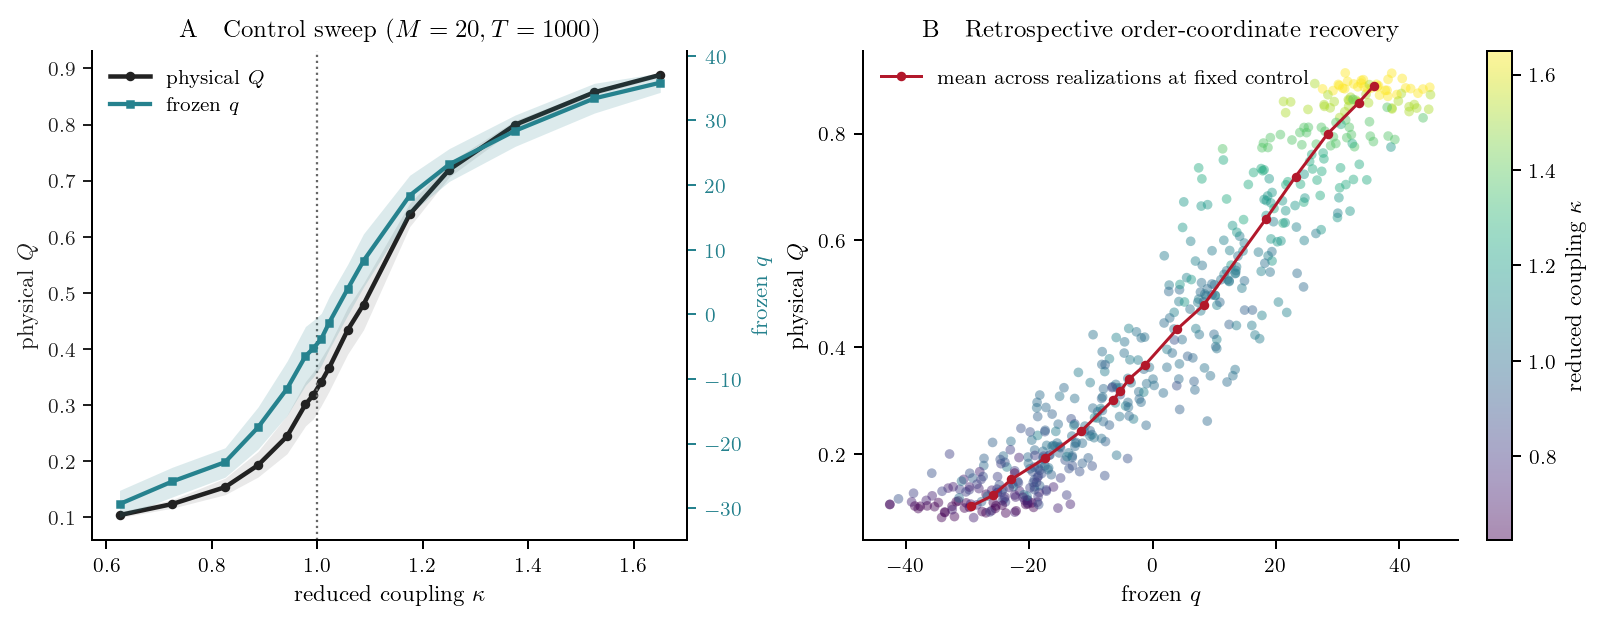

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.35), constrained_layout=True)
dual_tracking(axes[0], kuramoto, control='kappa', Q='Q', q='q', q_sign=-1, q_color=COLORS[20], boundary=1.0, title='A\\quad Control sweep ($M=20,T=1000$)')
points = recovery_scatter(axes[1], kuramoto, Q='Q', q='q', control='kappa', q_sign=-1, title='B\\quad Retrospective order-coordinate recovery')
fig.colorbar(points, ax=axes[1], label='reduced coupling $\\kappa$')
plt.show()

### Full-population result: $M=N=32,T=1000$

<!-- The $1.5$ cutoff is a **workflow heuristic**, inherited from the [earlier CML protocol](../../docs/research/order-parameter-benchmarks/cml2d-protocol-260911.md), requiring $\lambda_1/\lambda_2\geq1.5$. It is not a physical law, a calibrated significance test, or a necessary condition for tracking $Q$. Here PC1/PC2 explain $27.76\%/18.78\%$, giving $1.478$; minimum leave-seed loading cosine is $.897$ (required $.8$), and coverage passes. The original screen remains unmet; it does **not** establish absence of order-related information. The plots show exploratory held-seed tracking by the unchanged, target-blind PC1—not a separately confirmed result or proof of a uniquely one-dimensional representation. -->

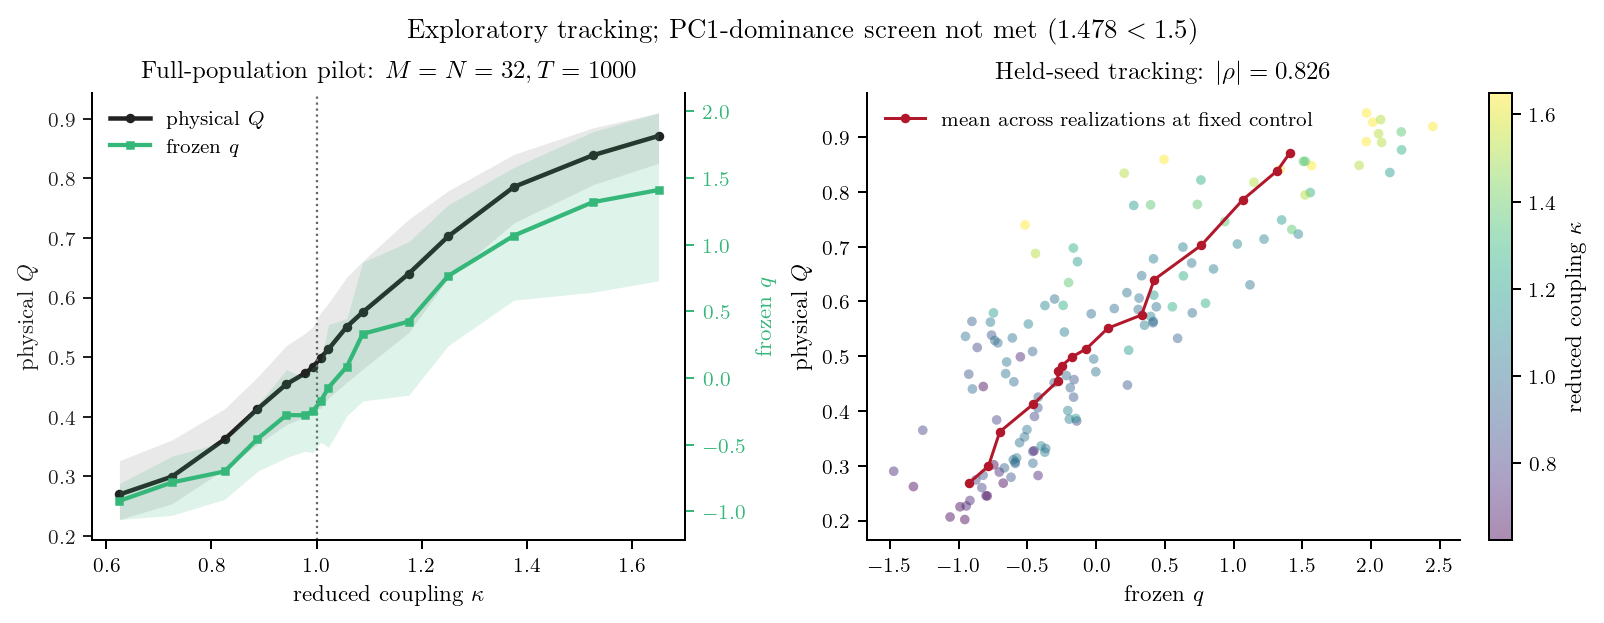

In [4]:
kur_full_root=ROOT/"data/order_parameter/kuramoto_full_observation_260916/primary"
kfull=None
if (kur_full_root/"analysis/summary.json").exists():
    report=json.loads((kur_full_root/"analysis/summary.json").read_text())
    if (kur_full_root/"analysis/scores.csv").exists():
        kfull=pd.read_csv(kur_full_root/"analysis/scores.csv").query("role == 'evaluation' and eligible")
        fig,axes=plt.subplots(1,2,figsize=(8.8,3.35),constrained_layout=True)
        dual_tracking(axes[0],kfull,control="control",Q="Q_reference",q="q",q_sign=report["display_sign"],
            q_color=COLORS[32],boundary=1,title=r"Full-population pilot: $M=N=32,T=1000$")
        points=recovery_scatter(axes[1],kfull,Q="Q_reference",q="q",control="control",q_sign=report["display_sign"],title=rf"Held-seed tracking: $|\rho|={report['results'][0]['rho']:.3f}$")
        axes[0].set_xlabel(r"reduced coupling $\kappa$")
        fig.colorbar(points,ax=axes[1],label=r"reduced coupling $\kappa$")
        if not report["passes"]: fig.suptitle(r"Exploratory tracking; PC1-dominance screen not met ($1.478 < 1.5$)")
        fig.savefig(FIGURE_DIR/"kuramoto-full-headline.png",dpi=300,bbox_inches="tight")
        fig.savefig(FIGURE_DIR/"kuramoto-full-headline.svg",bbox_inches="tight")
        plt.show()
    else:
        print("Full-population analysis failed:",report.get("reason",report["status"]))
else:
    print("M=N=32 p90 results pending. Available completed arm: M=20, T=1000, N=256; no multi-T results.")

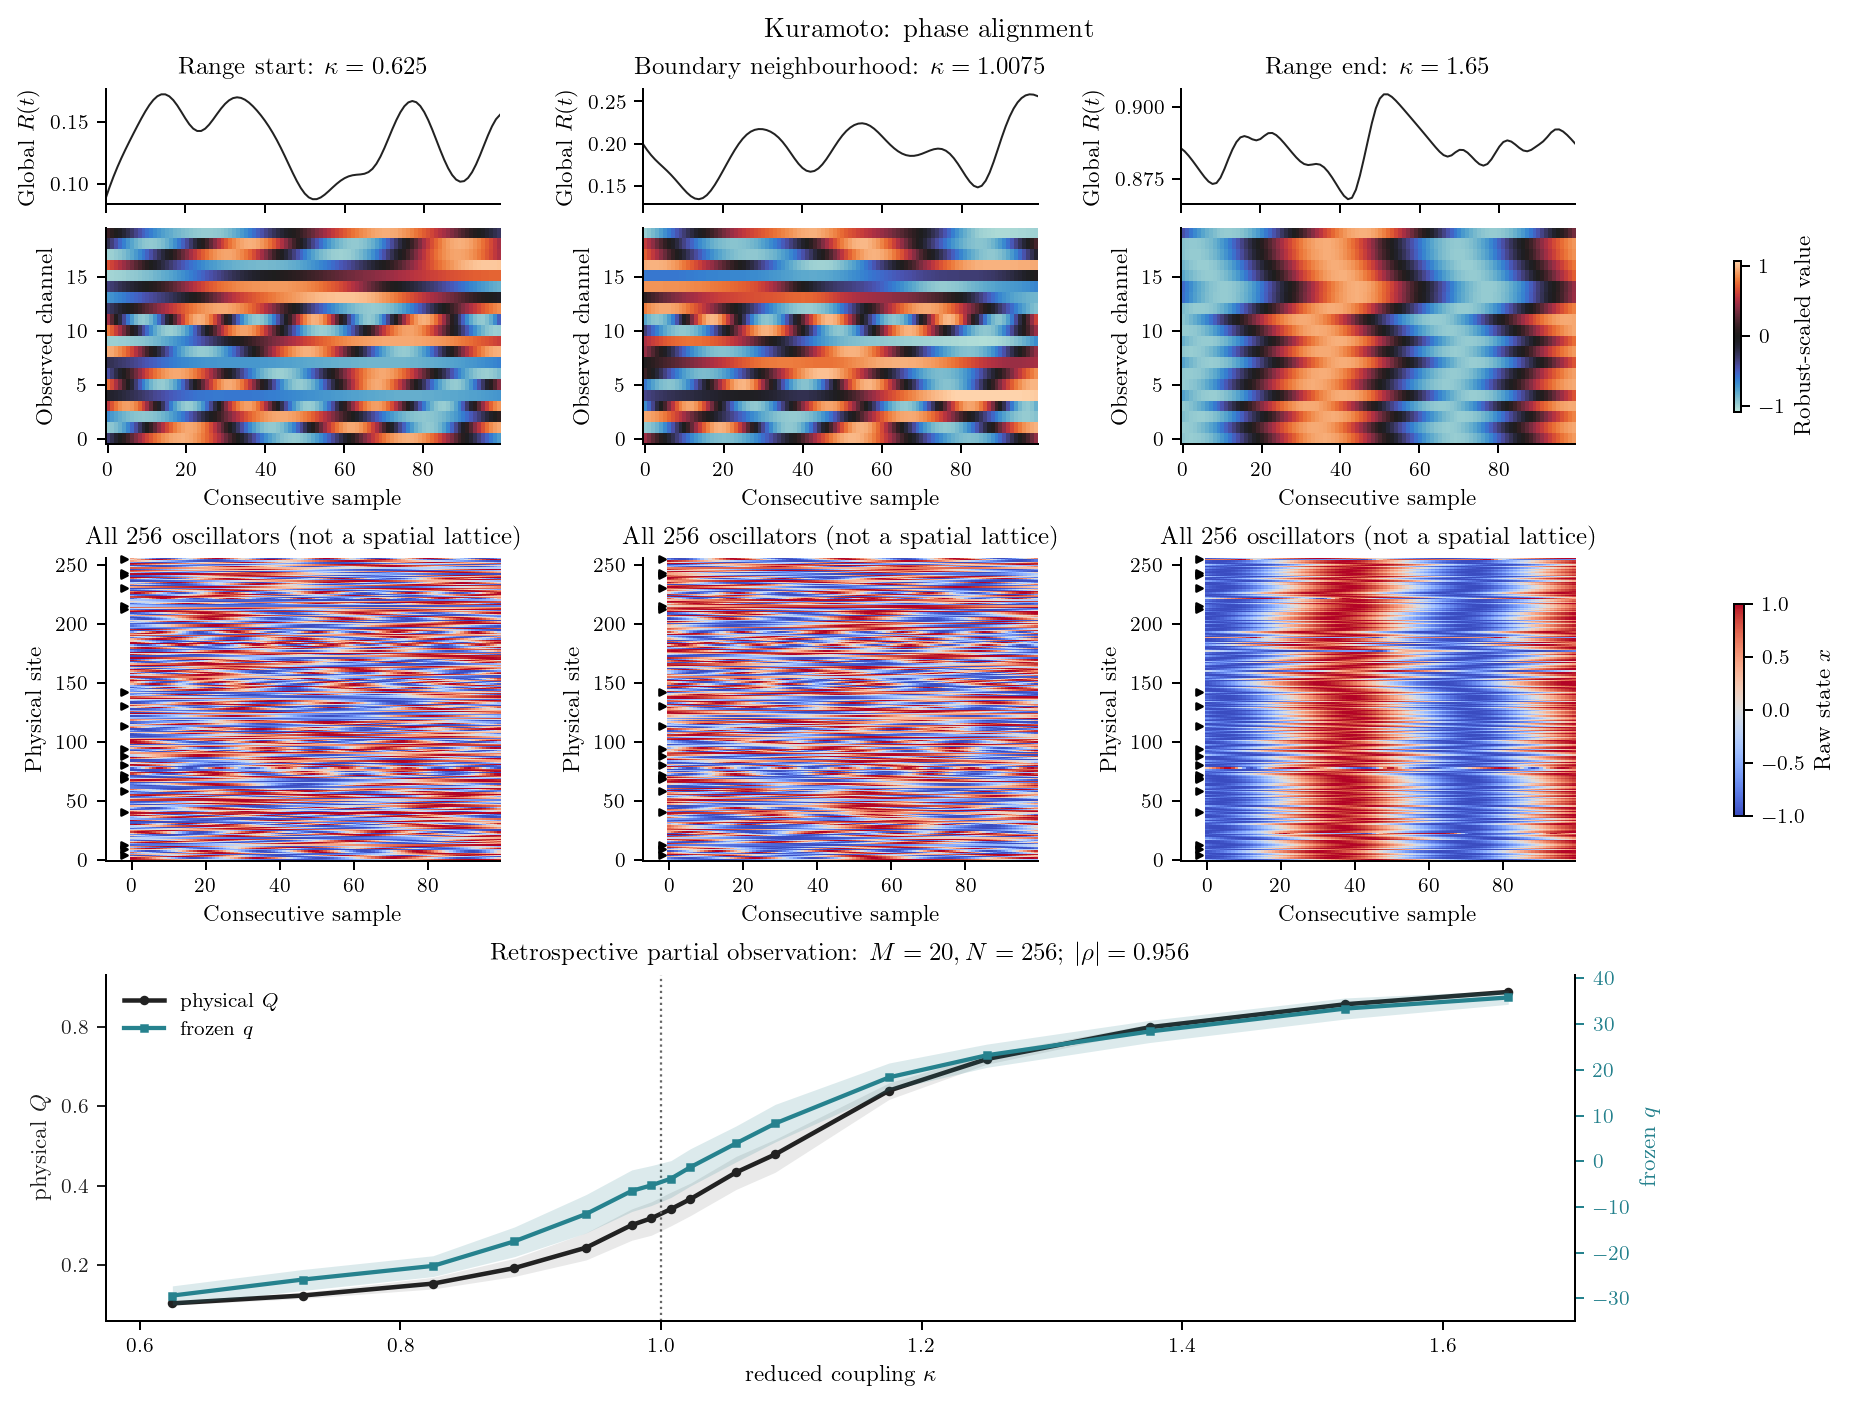

In [5]:
def tracking(ax):
    dual_tracking(ax,kuramoto,control="kappa",Q="Q",q="q",q_sign=-1,q_color=COLORS[20],boundary=1,
        title=r"Retrospective partial observation: $M=20,N=256$; $|\rho|=0.956$")
composite(snapshots(ROOT,"kuramoto",[.625,1.0075,1.65]),[.625,1.0075,1.65],r"\kappa",tracking,
    title="Kuramoto: phase alignment",output=FIGURE_DIR/"kuramoto-composite",
    field_label="All 256 oscillators (not a spatial lattice)",trace_label=r"Global $R(t)$")
plt.show()

### Full-population snapshots: $M=N=32$

Same 16 controls; 16 fresh Gaussian populations, eight development and eight held-out seeds; $T=1000$, $\Delta t_{\rm sample}=.1$, integration step .02, burn 200, disjoint 10,000-sample future $Q$. Every oscillator contributes one cosine channel: full **oscillator** coverage, not both quadratures. Snapshots use the first held seed and fixed control anchors, not selection for a good-looking result. The bottom row repeats the held-seed ensemble result, not within-time tracking.

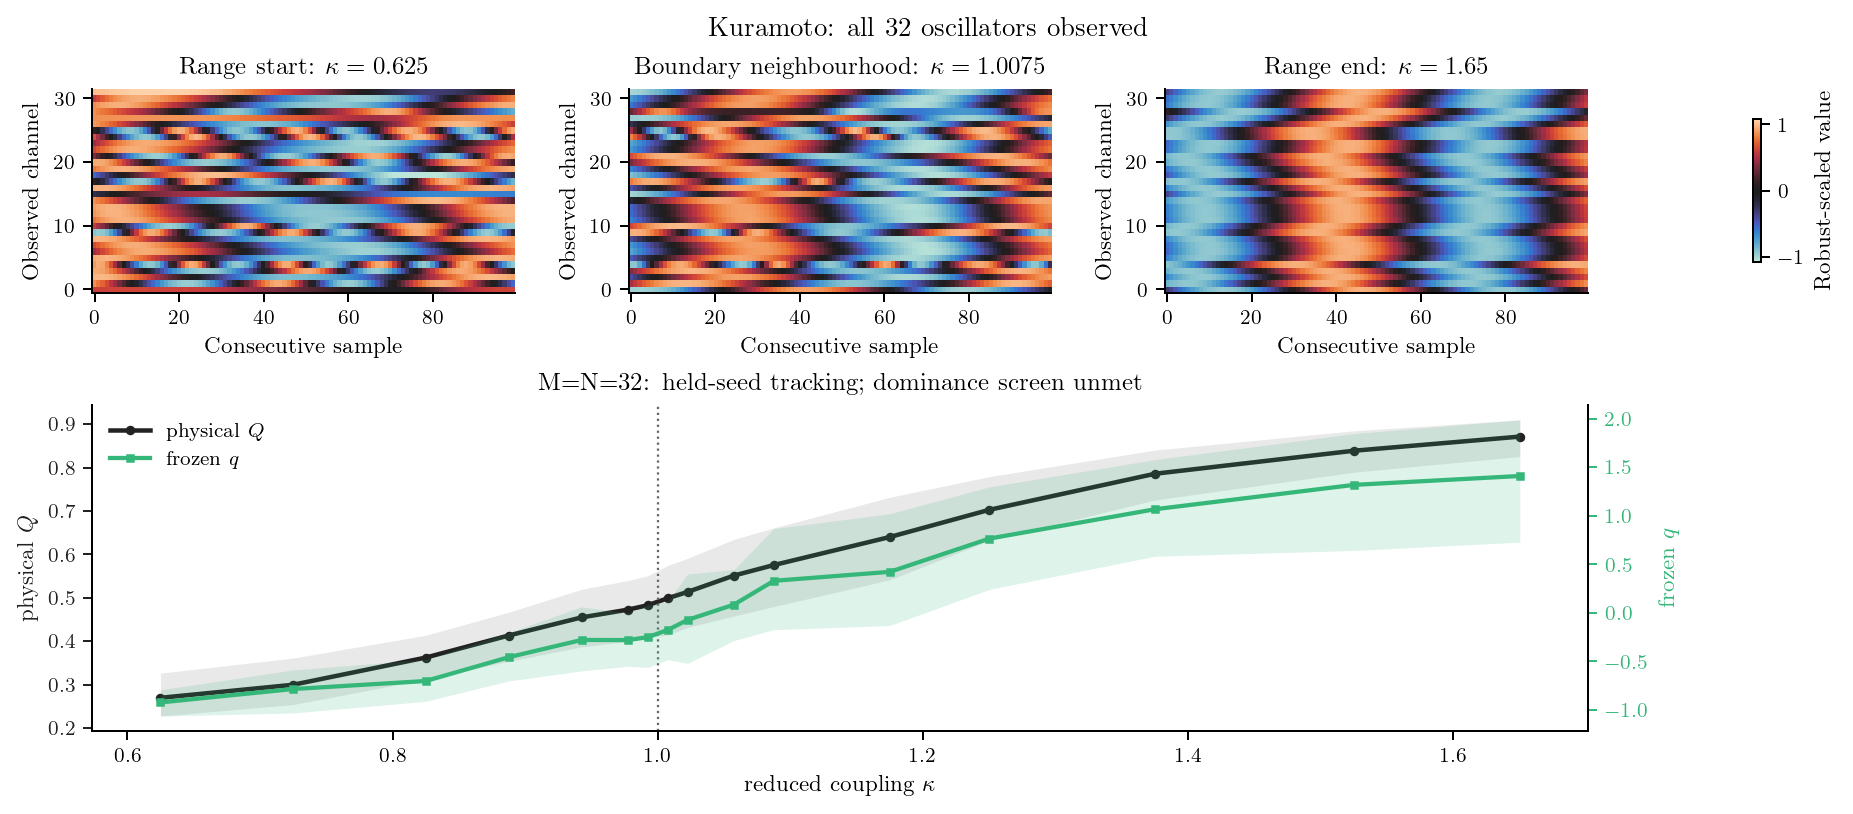

In [6]:
if kfull is not None and len(kfull):
    def tracking(ax):
        dual_tracking(ax,kfull,control="control",Q="Q_reference",q="q",q_sign=report["display_sign"],
            q_color=COLORS[32],boundary=1,title="M=N=32: held-seed tracking" + ("" if report["passes"] else "; dominance screen unmet"))
        ax.set_xlabel(r"reduced coupling $\kappa$")
    composite(corpus_examples(kur_full_root,[.625,1.0075,1.65],260916009),[.625,1.0075,1.65],r"\kappa",tracking,
        title="Kuramoto: all 32 oscillators observed",output=FIGURE_DIR/"kuramoto-full-composite")
    plt.show()

## 2. Stuart–Landau — collective oscillation amplitude

**System**

$$\dot z_j=(1-|z_j|^2+i\omega_j)z_j+K(Z-z_j),\qquad Z=N^{-1}\sum_jz_j.$$

**Params**

- $z_j$: complex amplitude and phase; $-|z_j|^2z_j$ saturates amplitude.
- $K=.8$: coupling to the population mean $Z$.
- $\omega_j$: uniform midpoint grid on $[2-\gamma,2+\gamma]$; $\gamma$ controls frequency spread.

**Phase diagram paper:** [Matthews & Strogatz (1990)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.65.1701) — Fig. 2(a), $(K,\gamma)$ phase diagram; Fig. 2(b), unsteady-region detail. The locking–unsteady line is numerical.

**Order-param paper:** [Same paper](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.65.1701) — Eq. (2), complex mean field; Fig. 1, its time-varying magnitude at $K=.8$.

**Control-parameter sweep:** broad $\gamma\in[.55,1.25]$, nine nonuniform points $.55,.65,.725,.775,.85,.95,1.05,1.15,1.25$; fine $\gamma\in[.680,.770]$, step $.005$, 19 points. Full oscillator coverage $M=N\in\{8,16,32\}$, real-part channels, $T\in\{100,500,1000\}$; fine confirmation uses $M=N=32,T=1000$ and eight fresh seeds.

**Order-parameter**

$$R(t)=|Z(t)|,\qquad Q=\langle R(t)\rangle_{\rm future}.$$

The collective oscillation amplitude. Increasing frequency spread disrupts locking; $R(t)$ can itself oscillate. Its mean $Q$ and variability $\operatorname{sd}_t(R)$ describe different aspects, both shown below.

**Results:** fine-boundary confirmation $|\rho(q,Q)|=.886$; $q$ and $Q$ share the steepest sampled interval $.720$–$.725$. This is a finite-$N$ result, not an exact thermodynamic boundary.

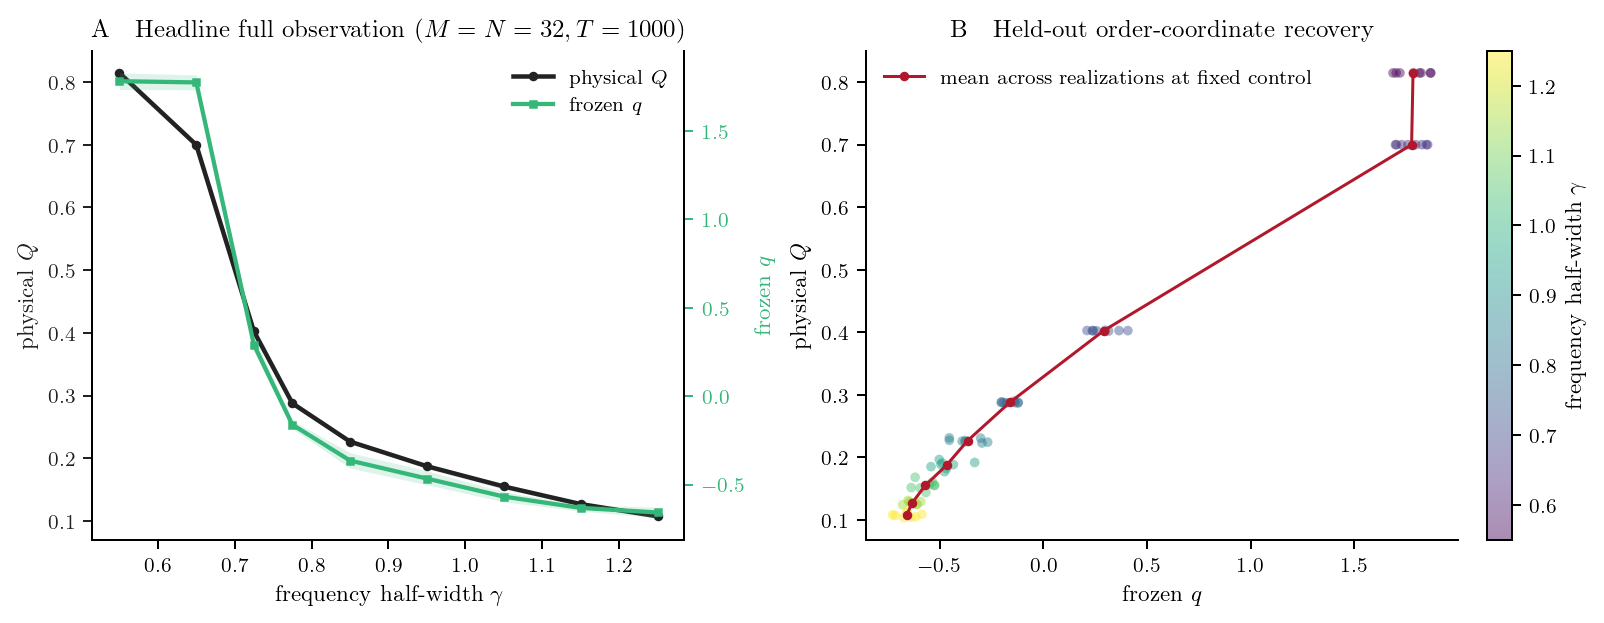

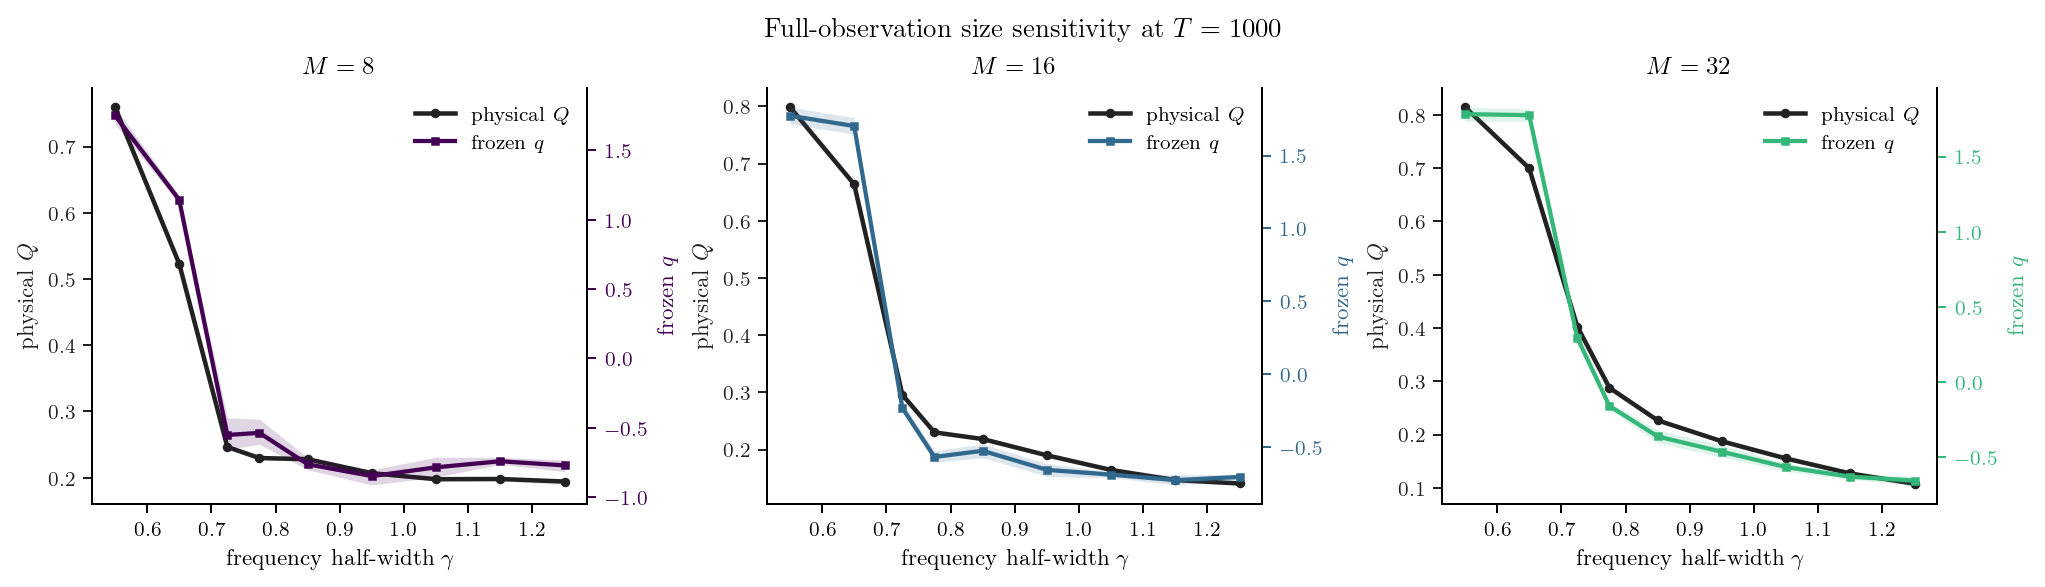

In [7]:
sl_headline = sl_primary.query('M == 32')
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.35), constrained_layout=True)
dual_tracking(axes[0], sl_headline, control='gamma', Q='Q_R_mean', q='q', q_sign=1, q_color=COLORS[32], title='A\\quad Headline full observation ($M=N=32,T=1000$)')
points = recovery_scatter(axes[1], sl_headline, Q='Q_R_mean', q='q', control='gamma', q_sign=1, title='B\\quad Held-out order-coordinate recovery')
fig.colorbar(points, ax=axes[1], label='frequency half-width $\\gamma$')
plt.show()
fig = size_tracking(sl_primary, control='gamma', Q='Q_R_mean', q='q', q_sign=1, boundary=None, title='Full-observation size sensitivity at $T=1000$')
plt.show()

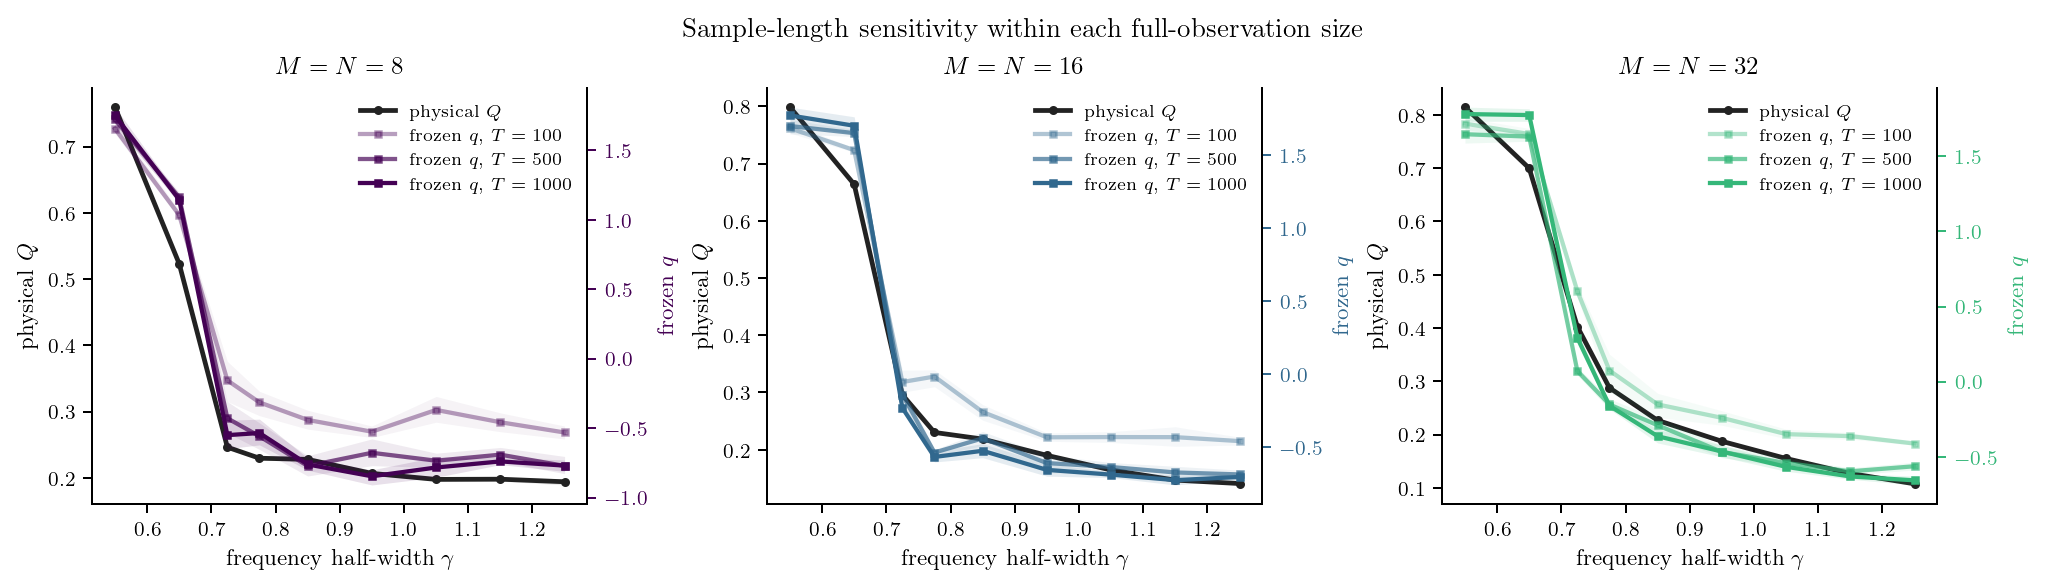

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11.25, 3.15), constrained_layout=True)
T_ALPHA = {100: 0.38, 500: 0.68, 1000: 1.0}
for ax, M in zip(axes, [8, 16, 32], strict=True):
    q_axis = ax.twinx()
    physical = bootstrap_curve(sl.query('M == @M and T == 1000'), 'gamma', 'Q_R_mean', seed=7211 + M)
    line_Q, = ax.plot(physical.gamma, physical['mean'], color=Q_COLOR, lw=1.9, marker='o', ms=2.6, label='physical $Q$')
    ax.fill_between(physical.gamma, physical.lower, physical.upper, color=Q_FILL, alpha=0.16, linewidth=0)
    lines = [line_Q]
    for T in [100, 500, 1000]:
        learned = bootstrap_curve(sl.query('M == @M and T == @T'), 'gamma', 'q', seed=8111 + M + T)
        line_q, = q_axis.plot(learned.gamma, learned['mean'], color=COLORS[M], alpha=T_ALPHA[T], lw=1.7, marker='s', ms=2.4, label=f'frozen $q$, $T={T}$')
        q_axis.fill_between(learned.gamma, learned.lower, learned.upper, color=COLORS[M], alpha=0.12 * T_ALPHA[T], linewidth=0)
        lines.append(line_q)
    ax.set(xlabel=CONTROL_LABELS['gamma'], ylabel='physical $Q$', title=f'$M=N={M}$')
    q_axis.set_ylabel('frozen $q$', color=COLORS[M])
    q_axis.tick_params(axis='y', colors=COLORS[M])
    paper_axis(ax)
    paper_axis(q_axis, right=True)
    ax.legend(lines, [line.get_label() for line in lines], frameon=False, fontsize=7, loc='best')
fig.suptitle('Sample-length sensitivity within each full-observation size')
plt.show()

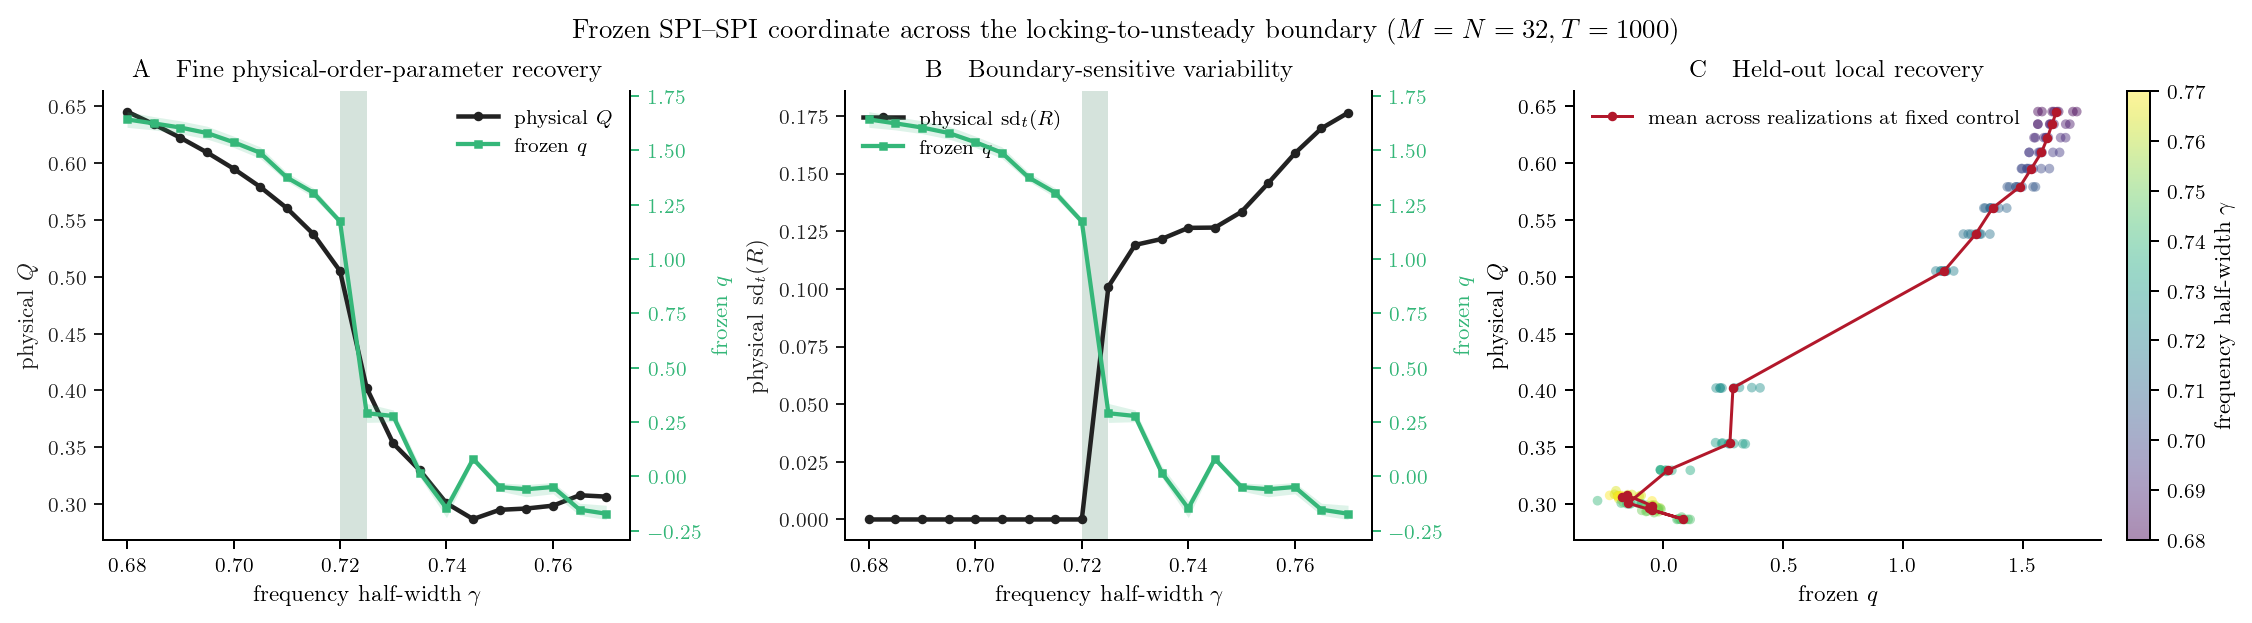

In [9]:
localization = sl_fine_summary['fine_boundary_localization']
q_interval = localization['q']['interval']
Q_interval = localization['Q_R_mean']['interval']
Q_sd_interval = localization['Q_R_sd']['interval']
fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.35), constrained_layout=True)
dual_tracking(axes[0], sl_fine, control='gamma', Q='Q_R_mean', q='q', q_sign=1, q_color=COLORS[32], title='A\\quad Fine physical-order-parameter recovery')
axes[0].axvspan(*Q_interval, color=Q_COLOR, alpha=0.1, linewidth=0)
axes[0].axvspan(*q_interval, color=COLORS[32], alpha=0.1, linewidth=0)
dual_tracking(axes[1], sl_fine, control='gamma', Q='Q_R_sd', q='q', q_sign=1, q_color=COLORS[32], title='B\\quad Boundary-sensitive variability', Q_label='physical $\\mathrm{sd}_t(R)$')
axes[1].set_ylabel('physical $\\mathrm{sd}_t(R)$')
axes[1].axvspan(*Q_sd_interval, color=Q_COLOR, alpha=0.1, linewidth=0)
axes[1].axvspan(*q_interval, color=COLORS[32], alpha=0.1, linewidth=0)
points = recovery_scatter(axes[2], sl_fine, Q='Q_R_mean', q='q', control='gamma', q_sign=1, title='C\\quad Held-out local recovery')
fig.colorbar(points, ax=axes[2], label='frequency half-width $\\gamma$')
fig.suptitle('Frozen SPI--SPI coordinate across the locking-to-unsteady boundary ($M=N=32,T=1000$)')
plt.show()
fine_metrics = pd.DataFrame([{'overall rho(q, mean R)': sl_fine_summary['full_association']['overall_spearman'], 'within-gamma rho': sl_fine_summary['full_association']['within_gamma_spearman'], 'gamma-mean rho': sl_fine_summary['full_pooled_gamma_mean_spearman'], 'rho(q, sd R)': sl_fine_summary['full_R_sd_association']['overall_spearman'], 'q steepest interval': tuple(q_interval), 'mean R steepest interval': tuple(Q_interval), 'sd R steepest interval': tuple(Q_sd_interval)}])
pass

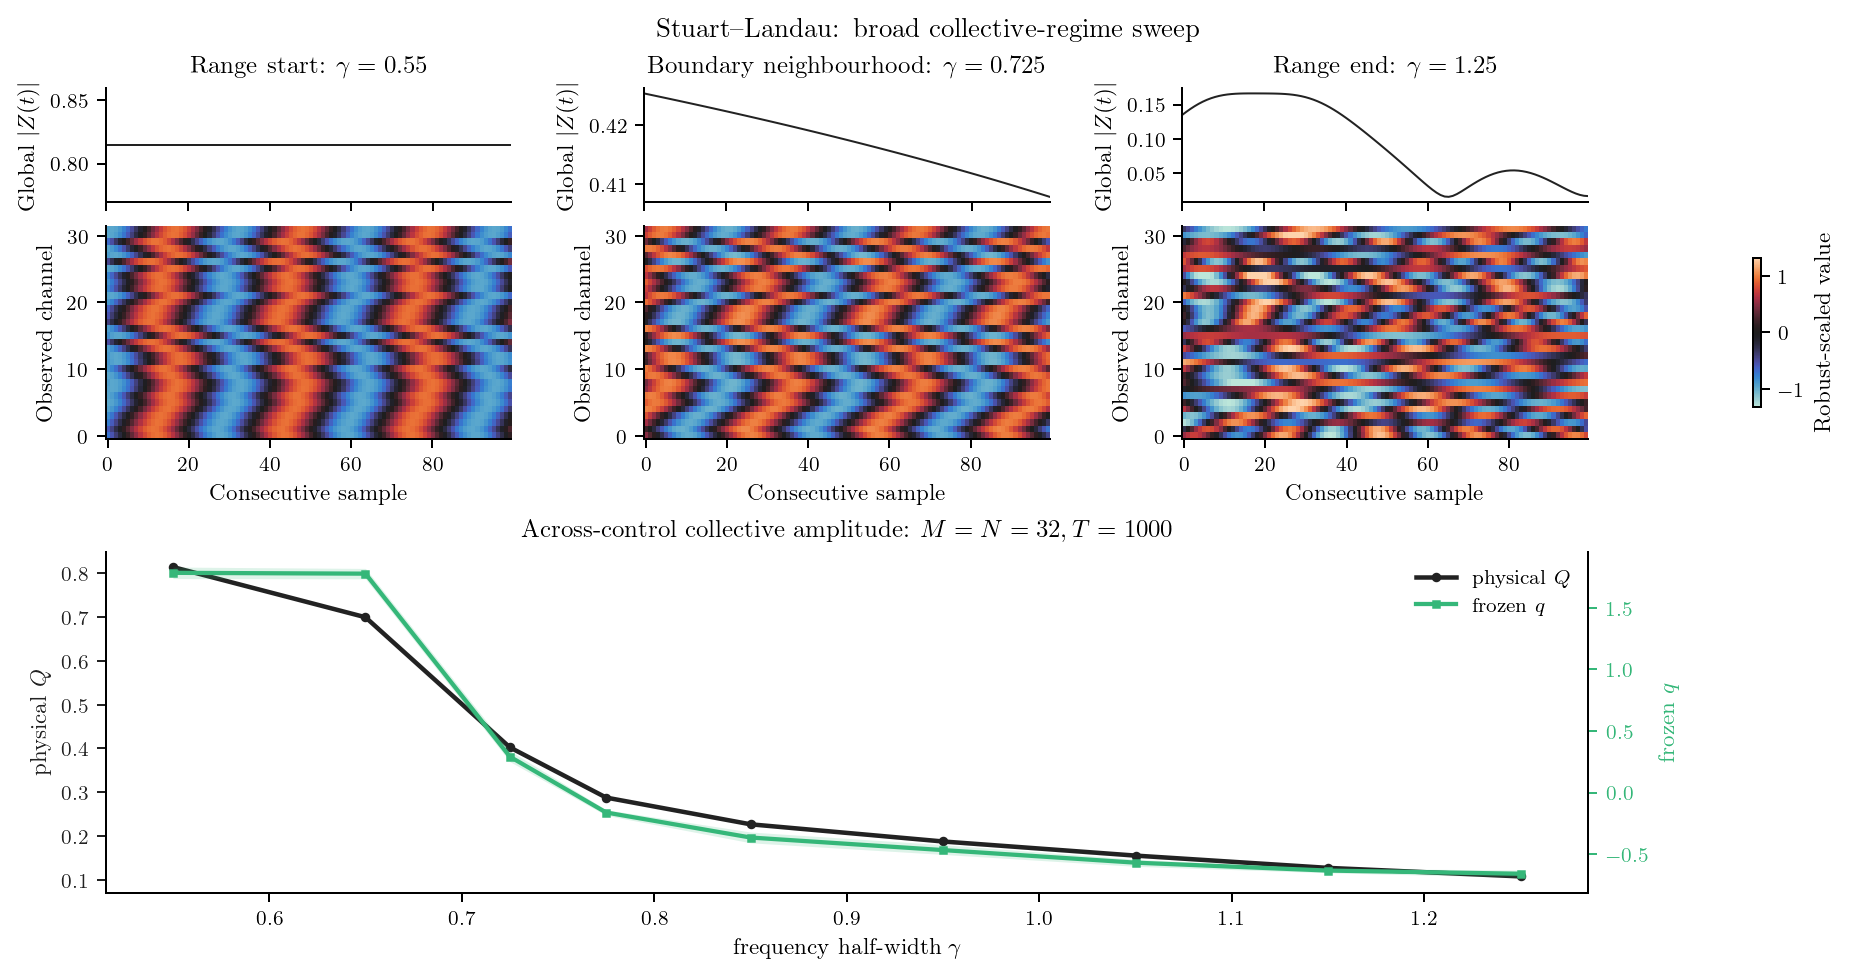

In [11]:
sl_headline=sl_primary.query("M == 32")
def tracking(ax):
    dual_tracking(ax,sl_headline,control="gamma",Q="Q_R_mean",q="q",q_sign=1,q_color=COLORS[32],
        title=r"Across-control collective amplitude: $M=N=32,T=1000$")
composite(snapshots(ROOT,"stuart-landau",[.55,.725,1.25]),[.55,.725,1.25],r"\gamma",tracking,
    title="Stuart--Landau: broad collective-regime sweep",output=FIGURE_DIR/"stuart-landau-composite",trace_label=r"Global $|Z(t)|$")
plt.show()

## 3. Miller–Huse — sign-domain symmetry breaking

**System**

$$x_{ij}(t+1)=(1-4g)f(x_{ij}(t))+g\sum_{(k,l)\in\mathrm{nn}(i,j)}f(x_{kl}(t)),\qquad f(x)=\begin{cases}-2-3x&x<-1/3,\\3x&|x|\leq1/3,\\2-3x&x>1/3.\end{cases}$$

**Params**

- $x_{ij}\in[-1,1]$: chaotic site state; piecewise-map slope magnitude fixed at $\mu=3$.
- $g$: coupling to four nearest neighbours; synchronous updates and periodic boundaries.
- $L=128$: square-lattice side; $N=L^2=16384$ sites.

**Phase diagram paper:** [Marcq, Chaté & Manneville (1997)](https://doi.org/10.1103/PhysRevE.55.2606) — pp. 2610–2611, order/susceptibility across coupling; finite-size critical estimates in Table I. Published $g_c=.20534(2)$; this is a one-control cut.

**Order-param paper:** [Same paper](https://doi.org/10.1103/PhysRevE.55.2606) — Eqs. (6)–(7), p. 2610: instantaneous spin magnetization and its mean absolute value. Original model: [Miller & Huse (1993)](https://doi.org/10.1103/PhysRevE.48.2528).

**Control-parameter sweep:** plotted confirmation $g\in[.185,.225, 9 steps]$. Dispersed $M\in\{8,16,32\}$, $T=1000$; eight fresh seeds; disjoint two-million-step reference. No multi-$T$ results are available.

**Order-parameter**

$$Q=\left\langle\left|L^{-2}\sum_{ij}\operatorname{sign}x_{ij}(t)\right|\right\rangle_t.$$

The imbalance between positive and negative domains. Stronger coupling allows one sign to dominate; the absolute value prevents whole-system sign flips from cancelling order.

**Results:** $\rho=.888$ pooled across $M$ in the 215/216-row exclusion sensitivity. The strict confirmation failed one row; this is not pristine confirmation.

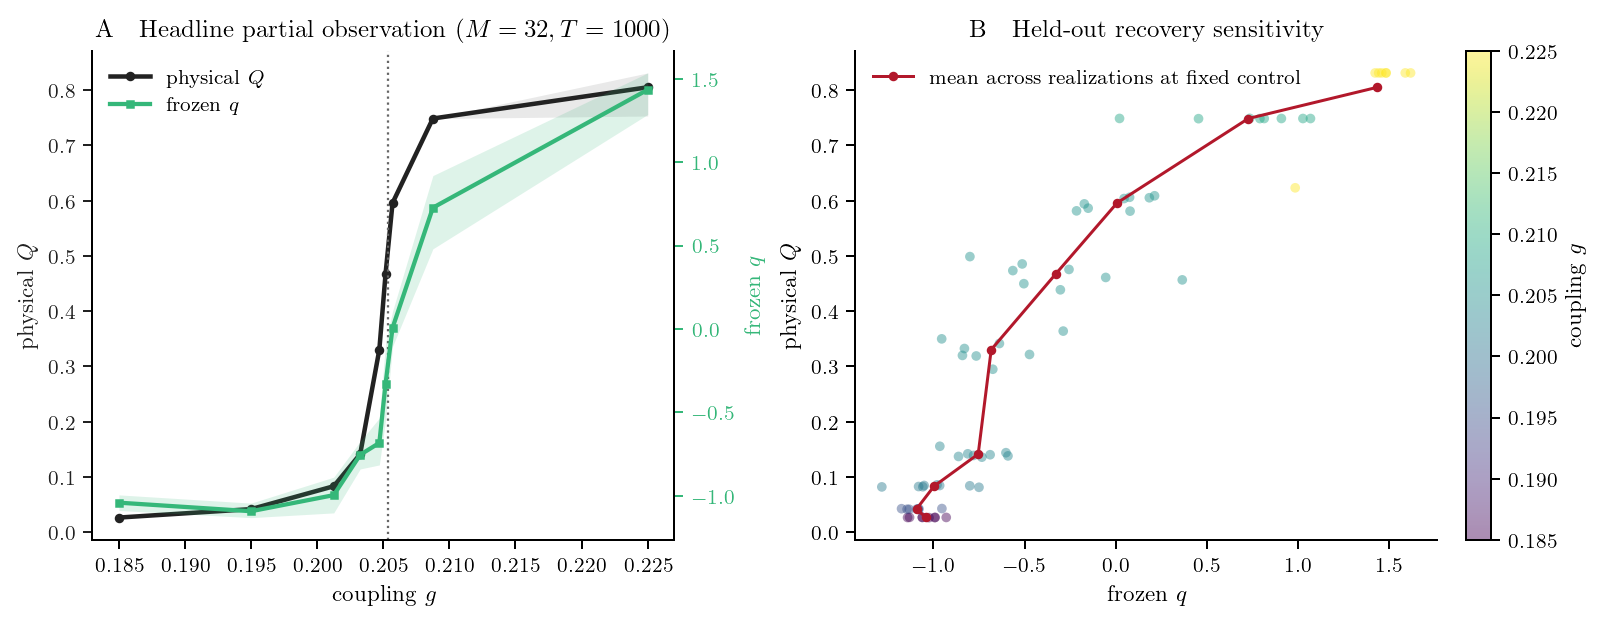

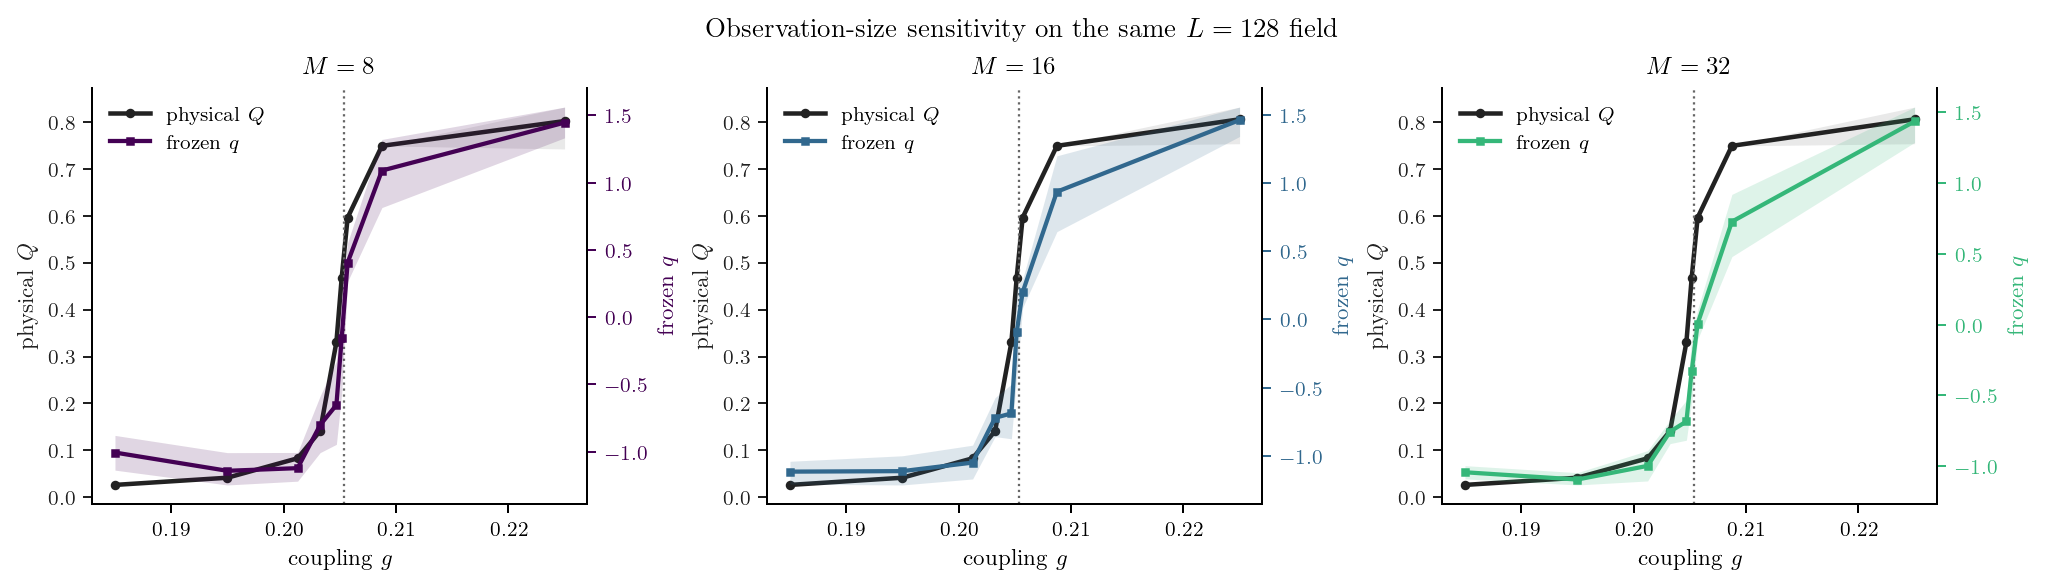

In [12]:
mh_headline = mh.query('M == 32')
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.35), constrained_layout=True)
dual_tracking(axes[0], mh_headline, control='g', Q='Q_spin_abs', q='q', q_sign=1, q_color=COLORS[32], boundary=0.20534, title='A\\quad Headline partial observation ($M=32,T=1000$)')
points = recovery_scatter(axes[1], mh_headline, Q='Q_spin_abs', q='q', control='g', q_sign=1, title='B\\quad Held-out recovery sensitivity')
fig.colorbar(points, ax=axes[1], label='coupling $g$')
plt.show()
fig = size_tracking(mh, control='g', Q='Q_spin_abs', q='q', q_sign=1, boundary=0.20534, title='Observation-size sensitivity on the same $L=128$ field')
plt.show()

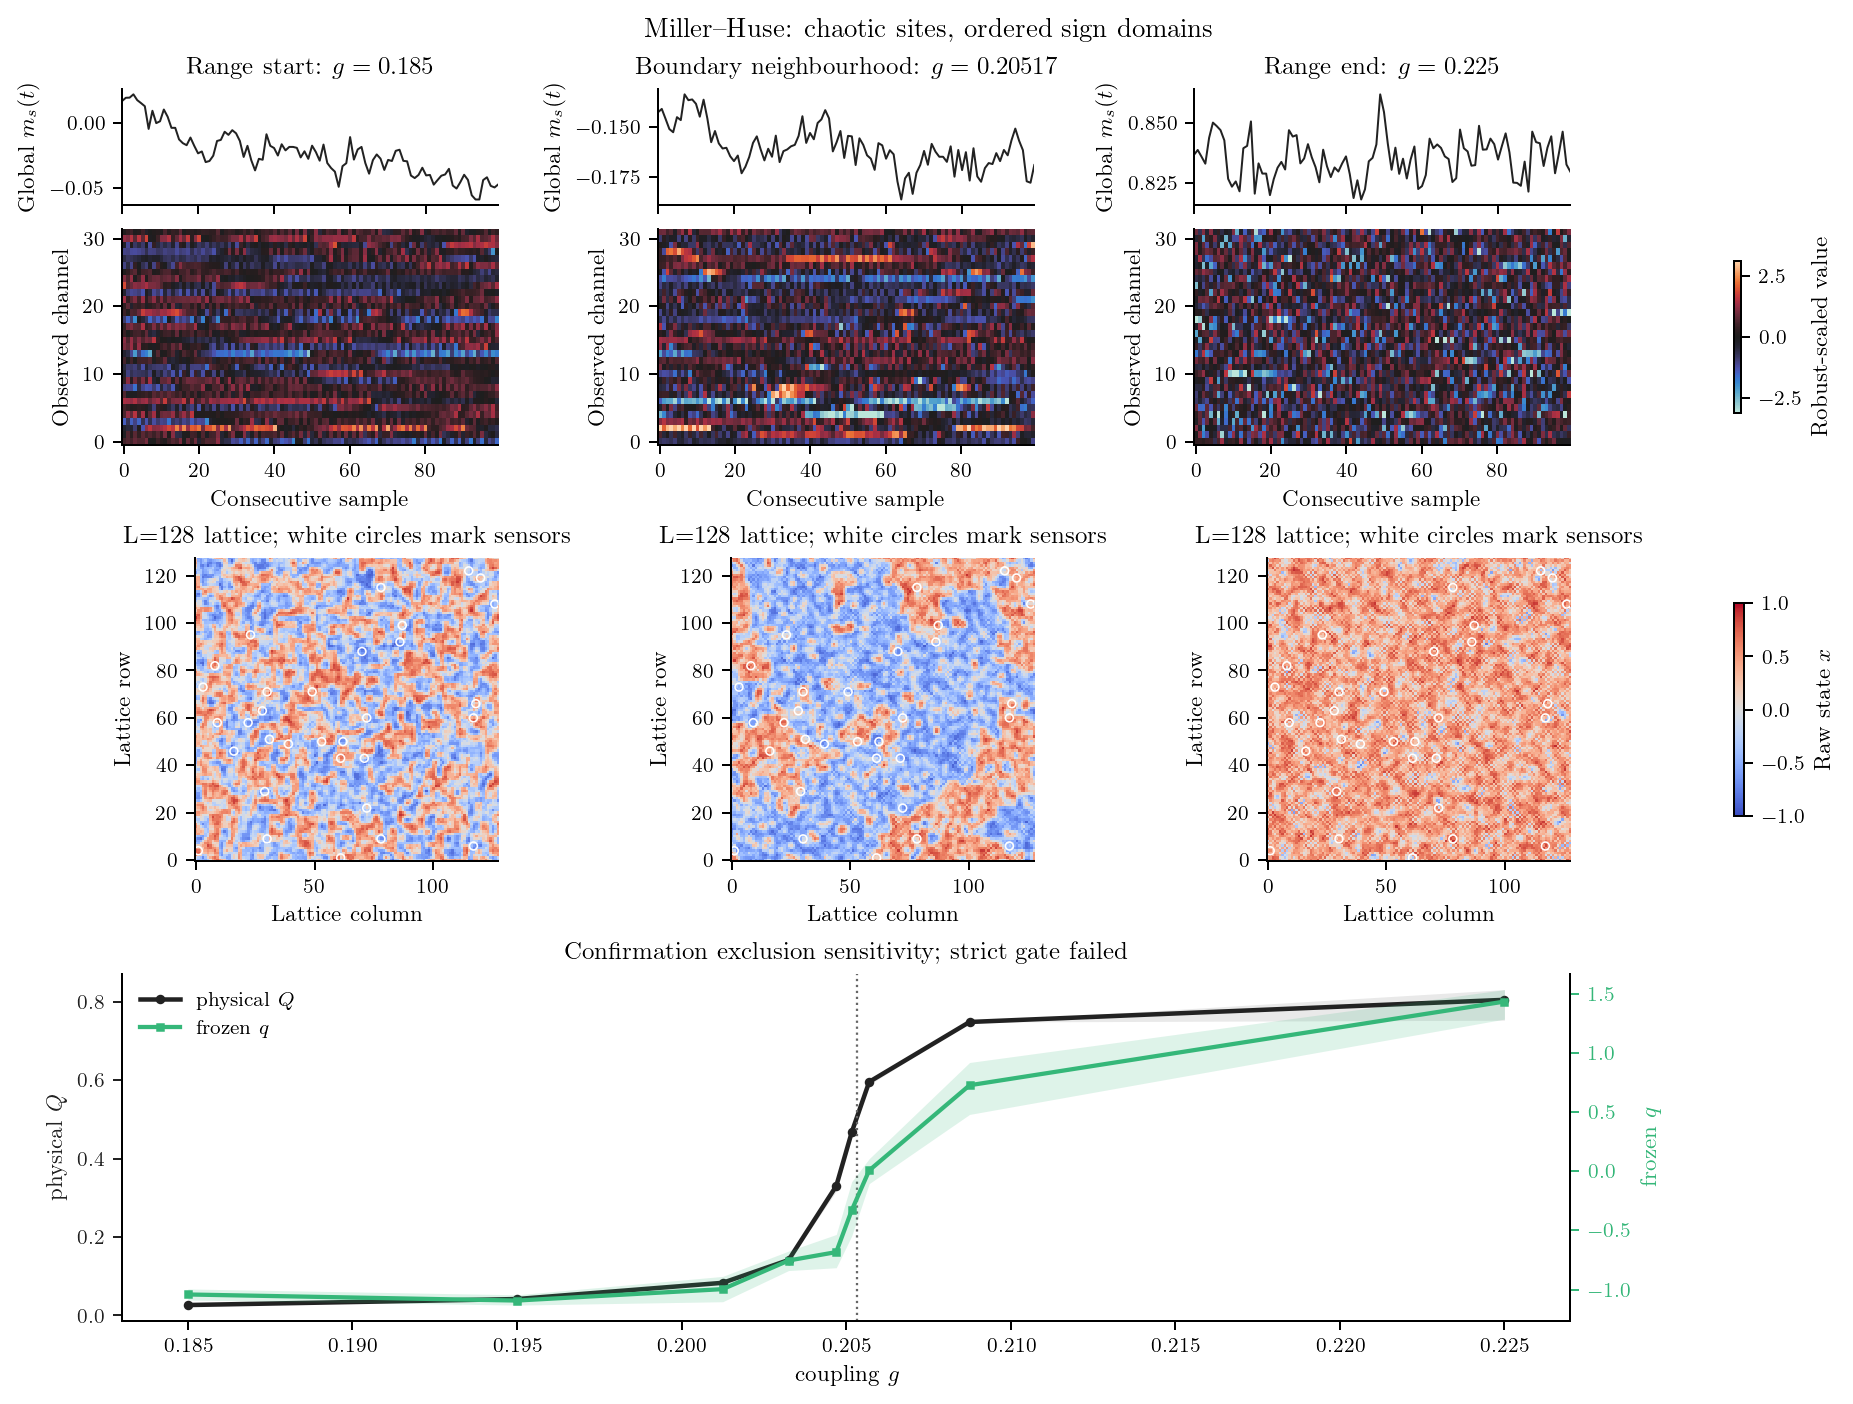

In [13]:
mh_headline=mh.query("M == 32")
def tracking(ax):
    dual_tracking(ax,mh_headline,control="g",Q="Q_spin_abs",q="q",q_sign=1,q_color=COLORS[32],boundary=.20534,
        title="Confirmation exclusion sensitivity; strict gate failed")
composite(snapshots(ROOT,"miller-huse",[.185,.20517,.225]),[.185,.20517,.225],"g",tracking,
    title="Miller--Huse: chaotic sites, ordered sign domains",output=FIGURE_DIR/"miller-huse-composite",
    lattice=True,field_label="L=128 lattice; white circles mark sensors",trace_label=r"Global $m_s(t)$")
plt.show()

## 4. Quadratic/Kaneko CML — pattern and temporal complexity diagnostics

**System**

$$x_i(t+1)=(1-\epsilon)f_\alpha(x_i(t))+\frac\epsilon2[f_\alpha(x_{i-1}(t))+f_\alpha(x_{i+1}(t))],\qquad f_\alpha(x)=1-\alpha x^2.$$

**Params**

- $\alpha$: local map nonlinearity.
- $\epsilon=.3$: nearest-neighbour mixing on a periodic **one-dimensional ring**.
- $N=512$: physical ring size; observations are dispersed sites.

**Phase diagram paper:** [Kaneko (1989)](https://doi.org/10.1016/0167-2789(89)90227-3) — pattern-selection, defect and pattern-competition/intermittency discussions. This is qualitative regime evidence, not an exact numerical boundary for our cut. [Long-transient caveat for the quadratic lattice](https://chaos.phys.msu.ru/loskutov/PDF/TMPh_quadratic_cml.PDF).

**Order-param paper:** no canonical order-parameter source for these exact two diagnostics. [Kaneko (1989)](https://doi.org/10.1016/0167-2789(89)90227-3) discusses entropy/spectral quantification of the regimes; our precise operational definitions are below and in [the diagnostic implementation](../../src/cml_order_parameter.py). They are not claimed as Kaneko's published order parameters.

**Control-parameter sweep:** $\alpha\in[1.60,2.00]$, step $.01$, 41 points; $M\in\{8,16,32\}$, $T=1000$. Four development and four held seeds; two-million-step burn, 20,000-step future diagnostics. No multi-$T$ results are available.

**Order-parameter / physical diagnostics**

$$Q_H=-\frac{\sum_{k=1}^{B}p_k\log p_k}{\log B},\qquad Q_P=\sum_{k/\pi\in[.25,.45]}p_k^{\rm space}.$$

Here $p_k$ is normalized non-DC temporal power averaged over sites, and $p_k^{\rm space}$ is normalized spatial power averaged over time. $Q_H$ measures narrow-band versus broadband activity; $Q_P$ measures concentration in a fixed range of spatial wavelengths.

**Results:** exploratory regime tracking with the same frozen $q_1$ for both diagnostics, not canonical order-parameter recovery. The reorganisation near $1.74$–$1.76$ depends on basin and finite time; full-ring images are site-versus-time plots.

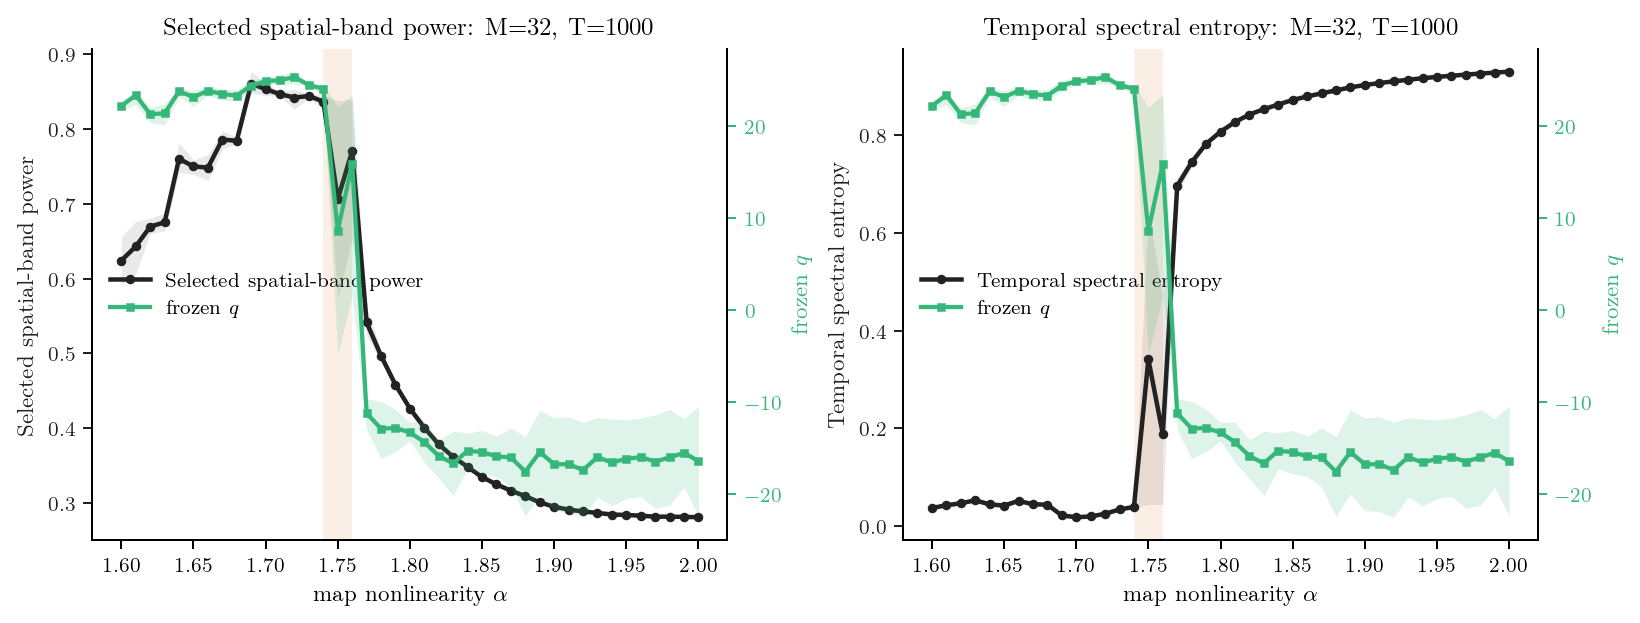

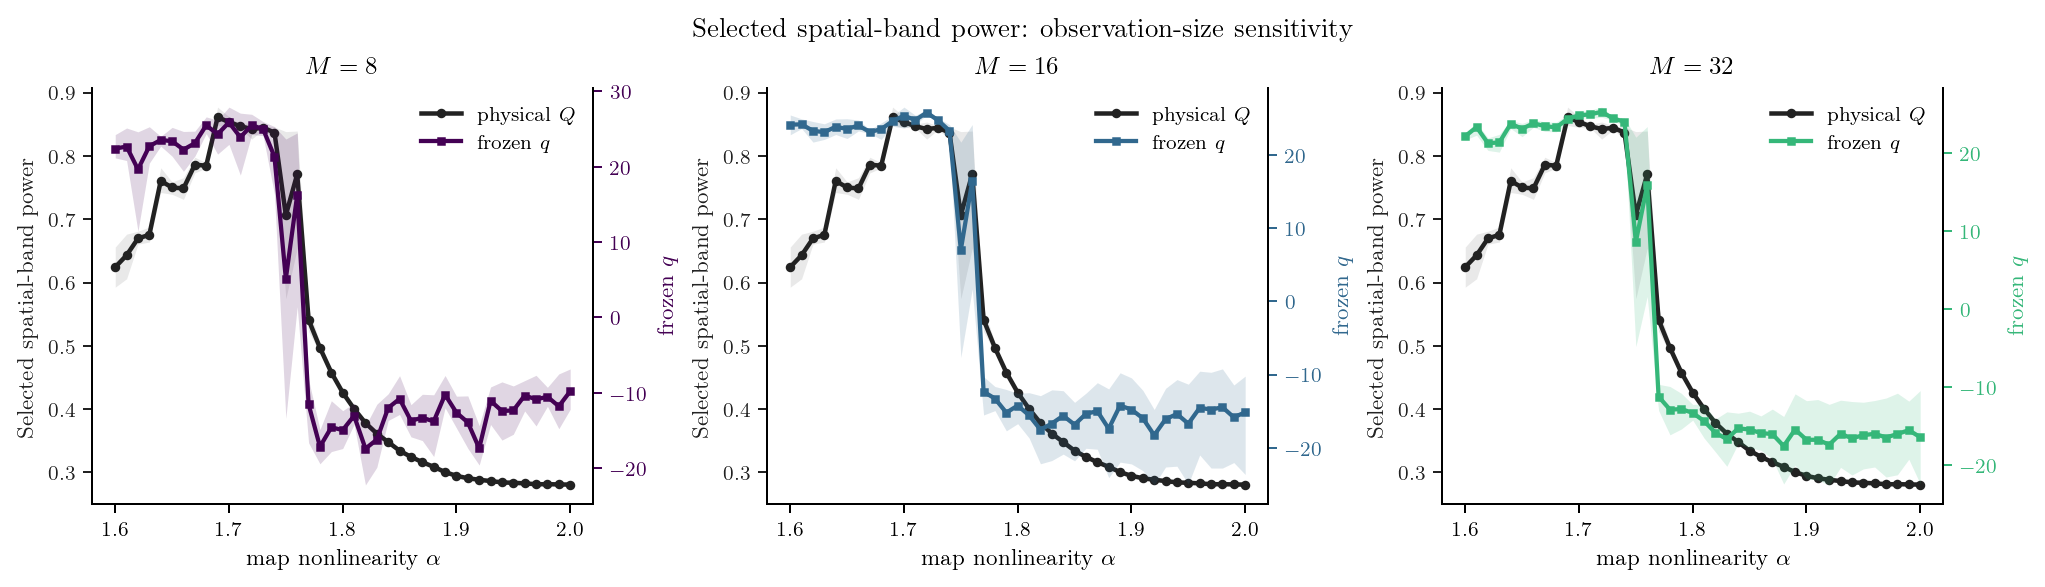

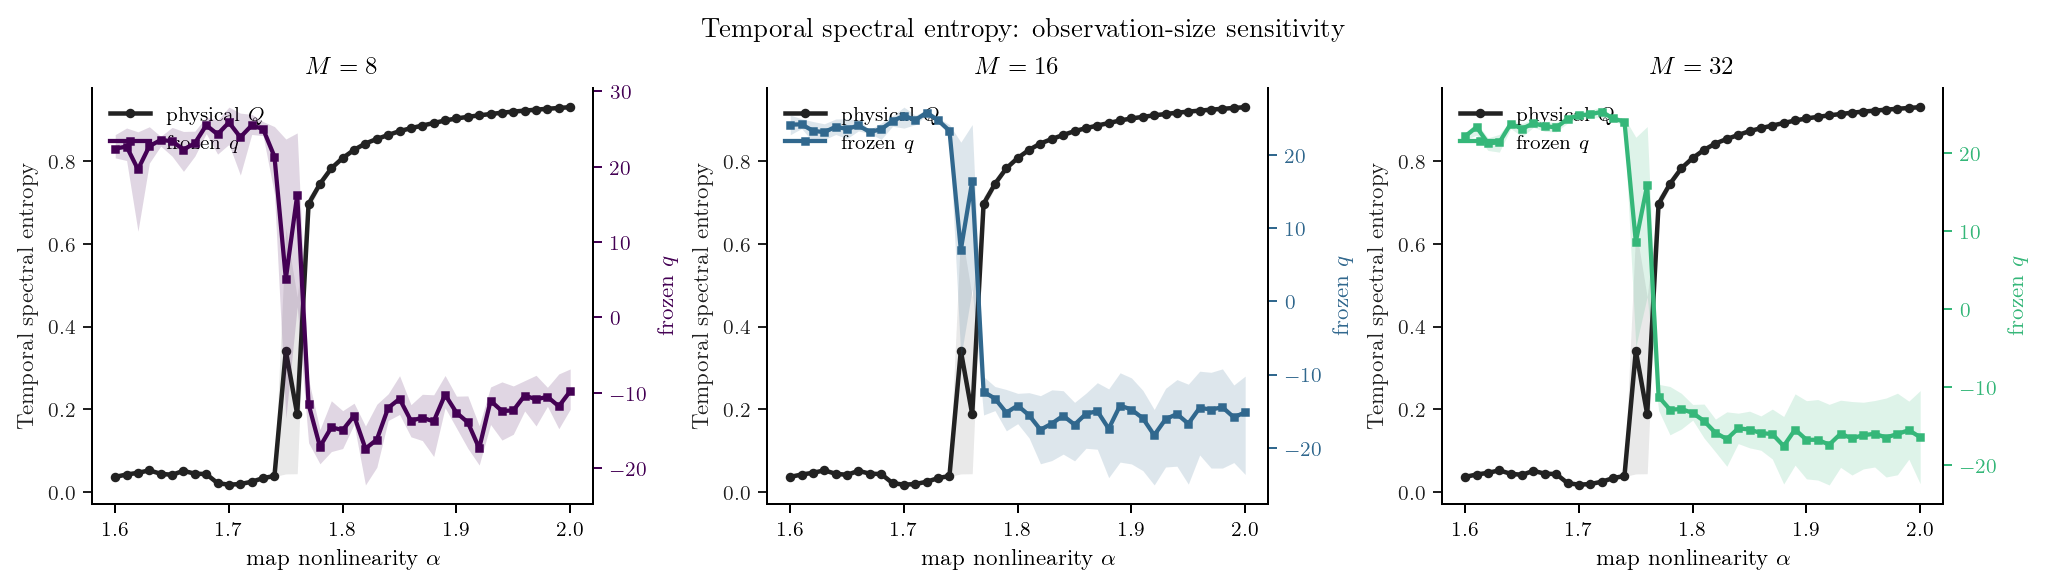

In [14]:
cml_headline=cml_held.query("M == 32")
cml_targets=[("Q_selected_band_power","Selected spatial-band power","band-power"),
             ("Q_temporal_entropy","Temporal spectral entropy","temporal-entropy")]
fig,axes=plt.subplots(1,2,figsize=(9,3.35),constrained_layout=True)
for ax,(target,label,_) in zip(axes,cml_targets):
    dual_tracking(ax,cml_headline,control="alpha",Q=target,q="q1",q_sign=-1,
        q_color=COLORS[32],Q_label=label,title=label+": M=32, T=1000")
    ax.set_ylabel(label)
    ax.get_legend().set_loc("center left")
    ax.axvspan(1.74,1.76,color="#d95f02",alpha=.1,lw=0)
plt.show()
for target,label,_ in cml_targets:
    fig=size_tracking(cml_held,control="alpha",Q=target,q="q1",q_sign=-1,boundary=None,title=label+": observation-size sensitivity")
    for ax in fig.axes:
        if ax.get_ylabel()==r"physical $Q$": ax.set_ylabel(label)
    plt.show()

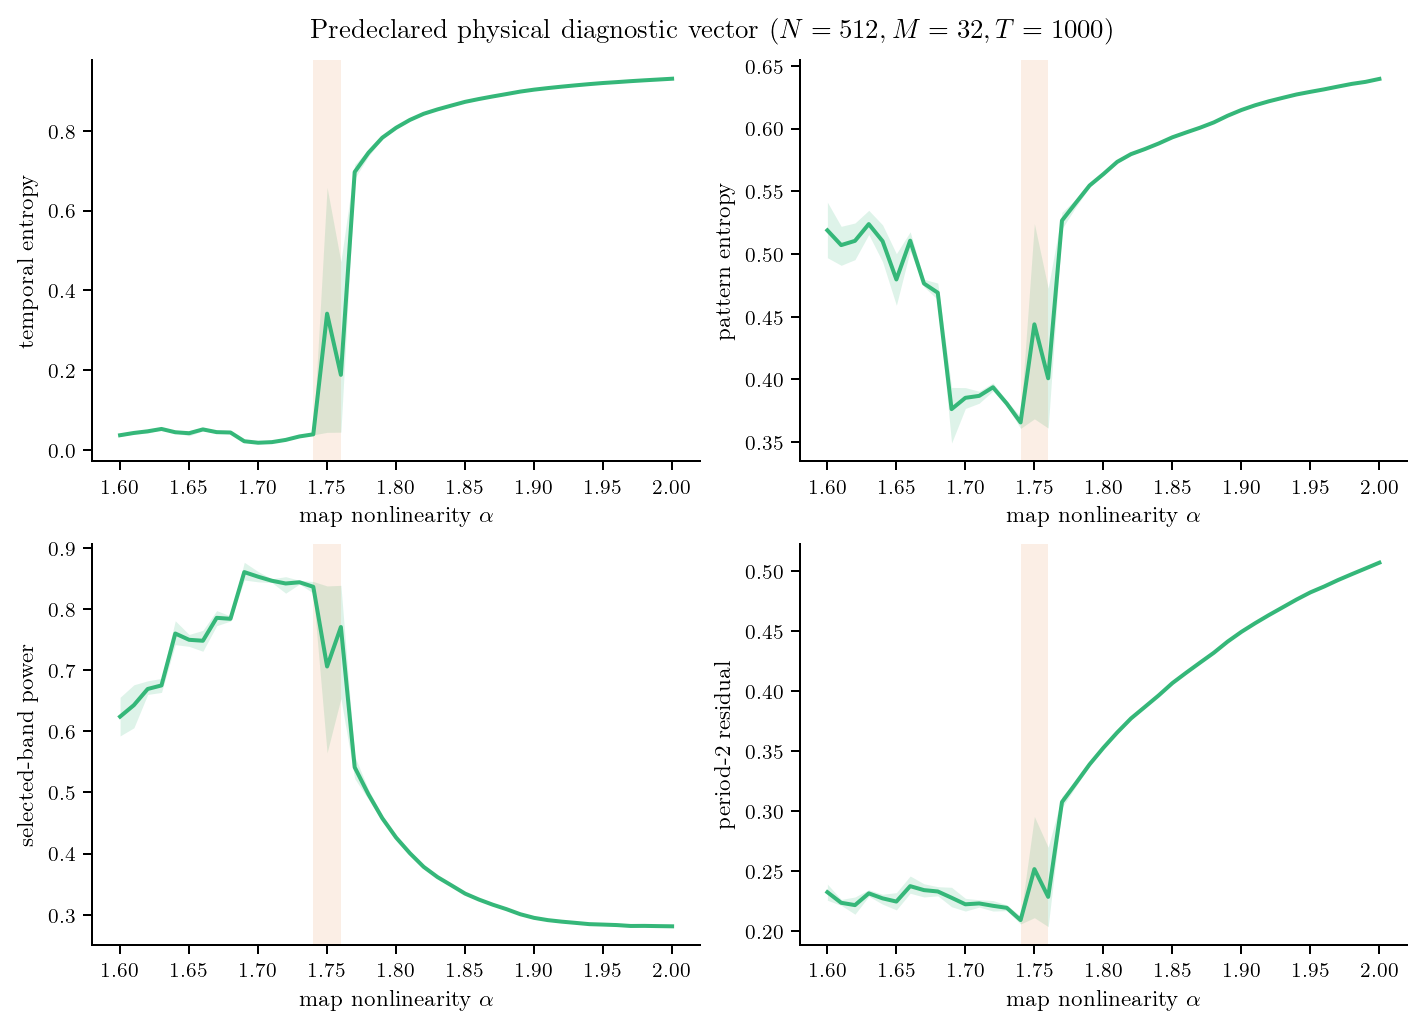

In [15]:
component_labels = {'Q_temporal_entropy': 'temporal entropy', 'Q_pattern_entropy': 'pattern entropy', 'Q_selected_band_power': 'selected-band power', 'Q_period2_residual': 'period-2 residual'}
fig, axes = plt.subplots(2, 2, figsize=(7.8, 5.6), constrained_layout=True)
for ax, (column, label) in zip(axes.flat, component_labels.items(), strict=True):
    curve = bootstrap_curve(cml_held.query('M == 32'), 'alpha', column, bootstraps=2000, seed=4111)
    ax.plot(curve.alpha, curve['mean'], color=COLORS[32], lw=1.6)
    ax.fill_between(curve.alpha, curve.lower, curve.upper, color=COLORS[32], alpha=0.16, linewidth=0)
    ax.axvspan(1.74, 1.76, color='#d95f02', alpha=0.1, linewidth=0)
    ax.set(xlabel='map nonlinearity $\\alpha$', ylabel=label)
    paper_axis(ax)
fig.suptitle('Predeclared physical diagnostic vector ($N=512,M=32,T=1000$)')
plt.show()

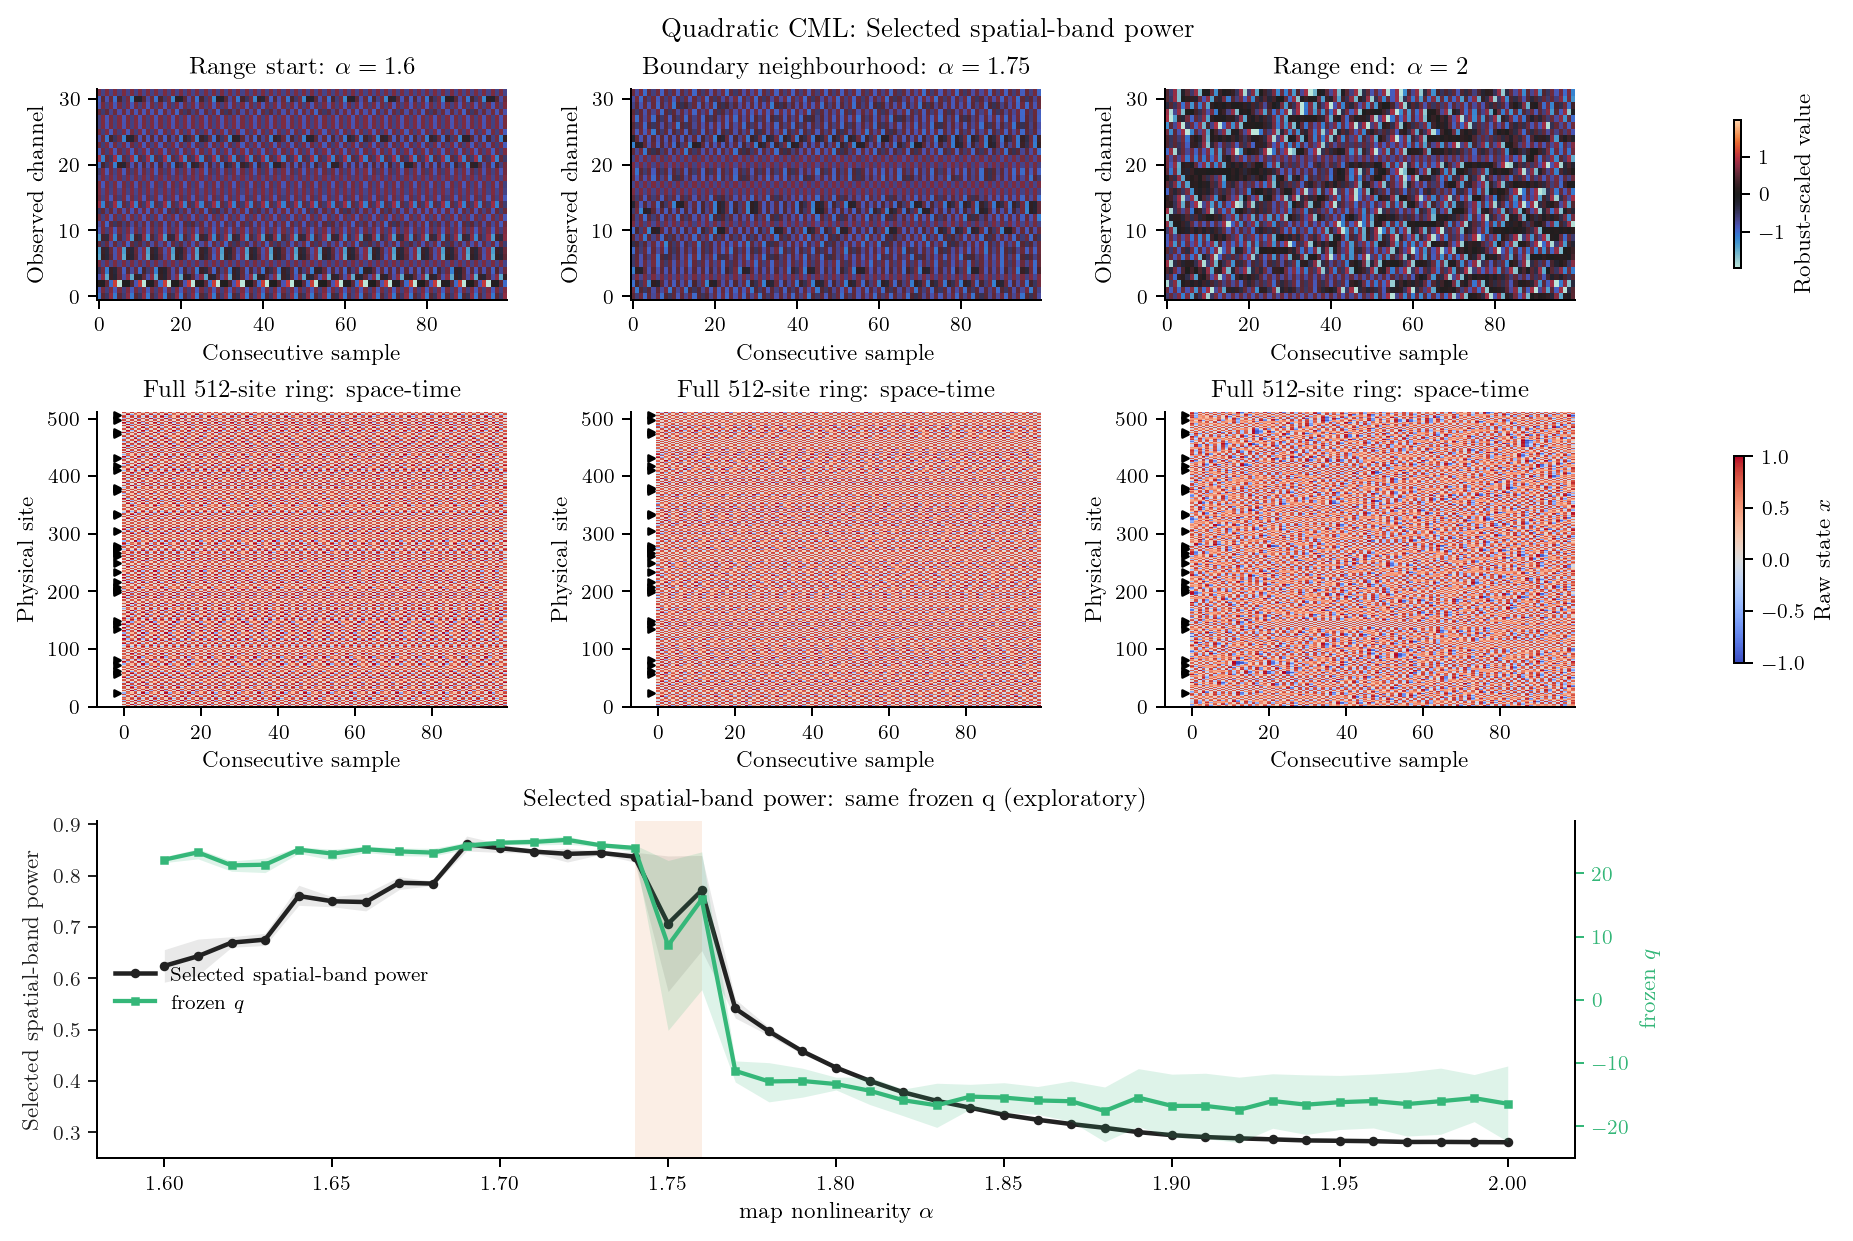

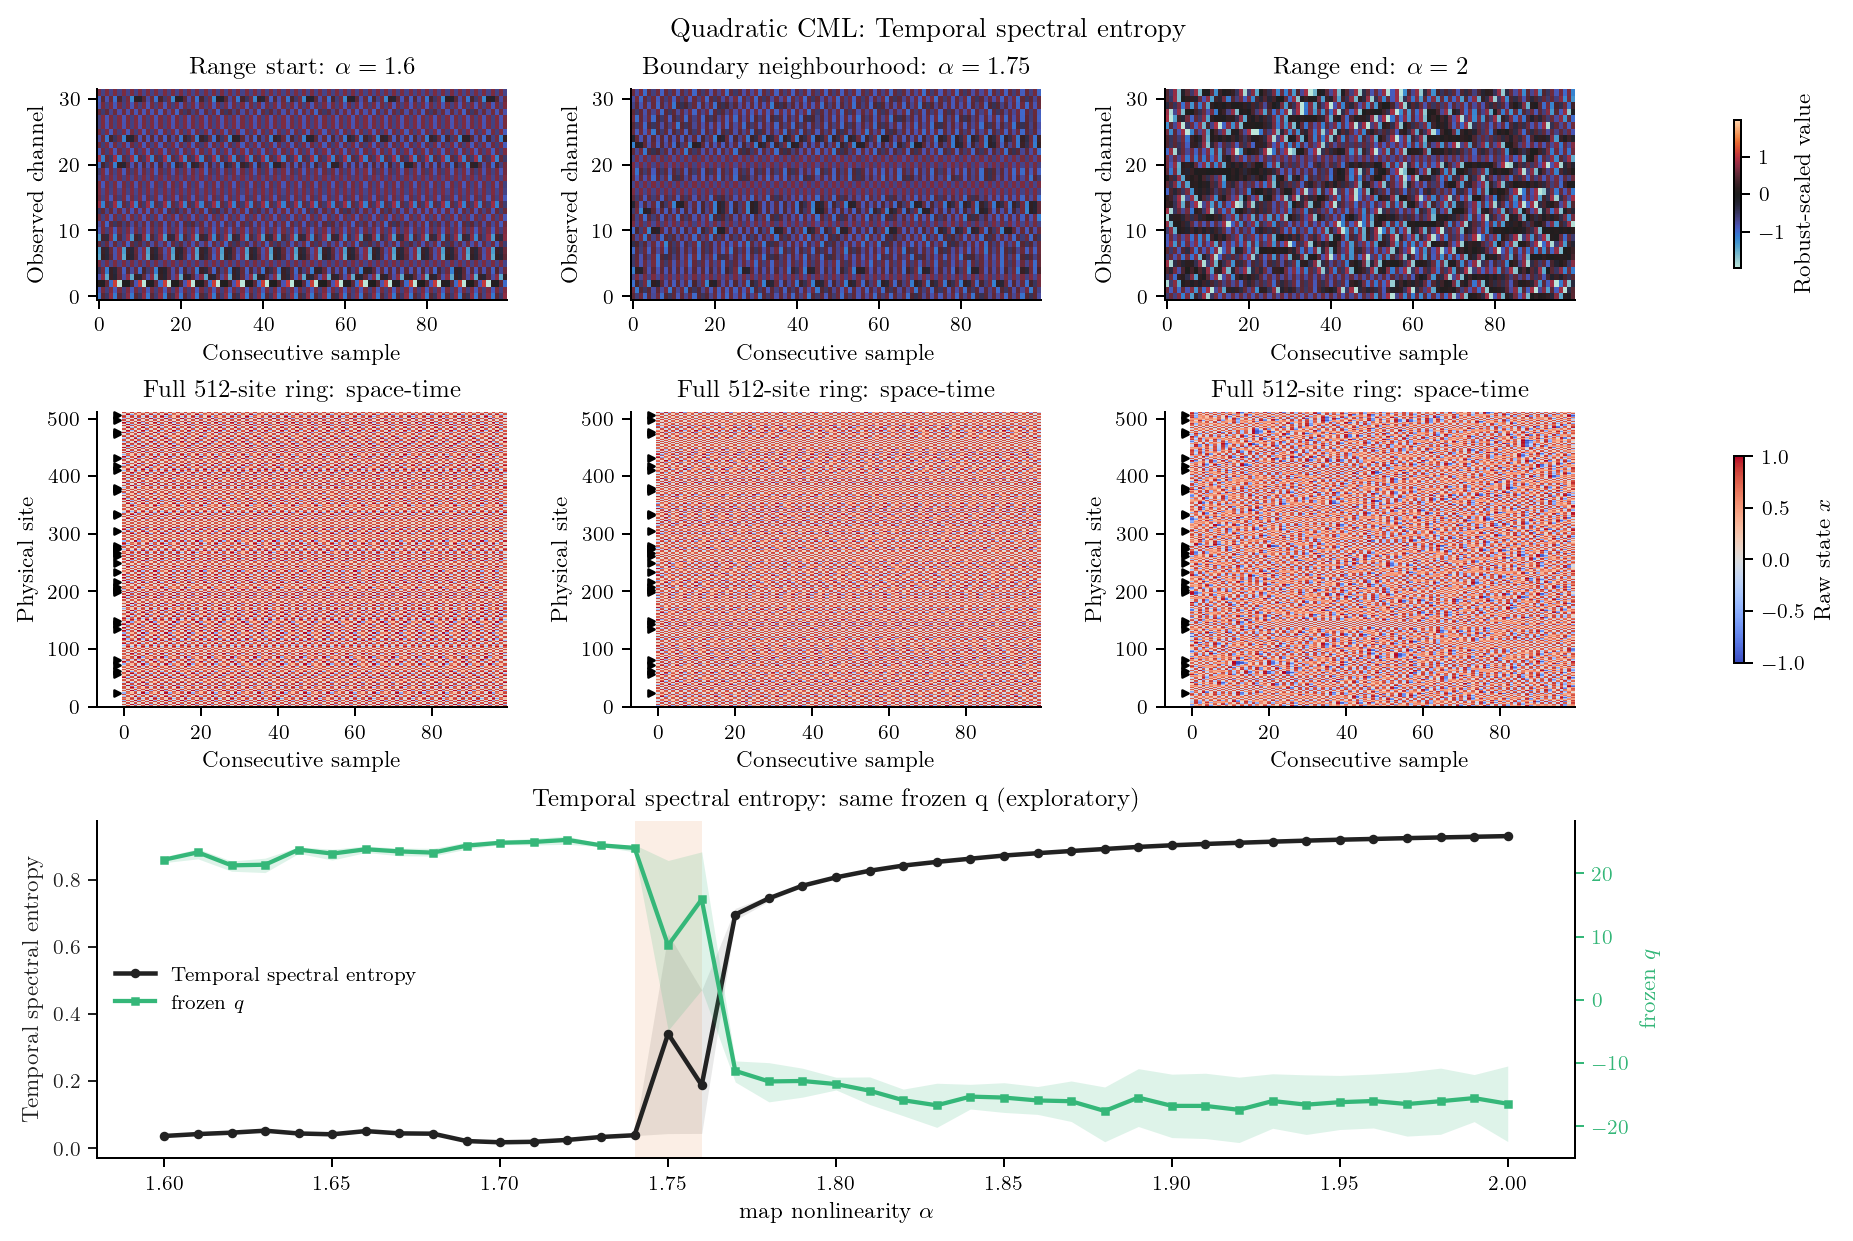

In [16]:
cml_headline=cml_held.query("M == 32")
for target,label,slug in [("Q_selected_band_power","Selected spatial-band power","band-power"),
                          ("Q_temporal_entropy","Temporal spectral entropy","temporal-entropy")]:
    def tracking(ax):
        dual_tracking(ax,cml_headline,control="alpha",Q=target,q="q1",q_sign=-1,q_color=COLORS[32],
            Q_label=label,title=label+": same frozen q (exploratory)")
        ax.set_ylabel(label)
        ax.get_legend().set_loc("center left")
        ax.axvspan(1.74,1.76,color="#d95f02",alpha=.10,lw=0)
    composite(snapshots(ROOT,"quadratic-cml",[1.6,1.75,2.0]),[1.6,1.75,2.0],r"\alpha",tracking,
        title="Quadratic CML: "+label,output=FIGURE_DIR/("quadratic-cml-"+slug),field_label="Full 512-site ring: space-time")
    plt.show()

## 5. Two-dimensional logistic CML — collective period two

**System**

$$x_{ij}(t+1)=(1-4g)f_r(x_{ij}(t))+g\sum_{(k,l)\in\mathrm{nn}(i,j)}f_r(x_{kl}(t)),\qquad f_r(x)=rx(1-x).$$

**Params**

- $r$: local logistic-map parameter; $g=.2$: four-neighbour coupling.
- $L$: periodic square-lattice side; $N=L^2$; synchronous updates.
- Primary $L=256$, $N=65536$; small full-observation diagnostics use $L=6,8$.

**Phase diagram paper:** [Marcq, Chaté & Manneville (2006)](https://arxiv.org/html/nlin/0605004) — Fig. 1, collective bifurcation diagram at $g=.2$; Fig. 3 and Sec. 2, extrapolated boundary $r_c=3.86212(12)$; Sec. 3, other cuts in $(r,g)$.

**Order-param paper:** [Same paper](https://arxiv.org/html/nlin/0605004) — Eqs. (3)–(4), global mean and period-two order parameter.

**Control-parameter sweep:** $r\in[3.84,3.89, 17steps]$. Primary $M=32,T=1000$; pilot $M\in\{8,16,32\}$, $T\in\{100,500,1000\}$; independent paired confirmation $M\in\{16,32\}$, $T\in\{500,1000\}$. Eight pilot / 32 fresh confirmation seeds; 200,000-step burn and disjoint million-step reference.

**Order-parameter**

$$\bar x(t)=L^{-2}\sum_{ij}x_{ij}(t),\qquad Q=\langle|\bar x(2t+1)-\bar x(2t)|\rangle_t.$$

The separation between alternating global-mean levels. Increasing $r$ merges the two levels while individual sites remain chaotic. Mean activity itself is not $Q$; the quoted boundary is numerical and infinite-size, not exact for finite $L$.

**Results:** frozen dispersed-view confirmation $\rho=.883$, all 1408 primary/secondary records valid. Contiguous-patch transfer and small full-lattice tests failed their respective gates; these remain labelled diagnostics.

In [17]:
CML2D_ROOT=ROOT/"data/order_parameter/cml2d_period_doubling_260911"
cml2d_snapshot_dir=FIGURE_DIR/"cml2d-period-doubling"
cml2d_scores=pd.read_csv(CML2D_ROOT/"primary-analysis/scores.csv")

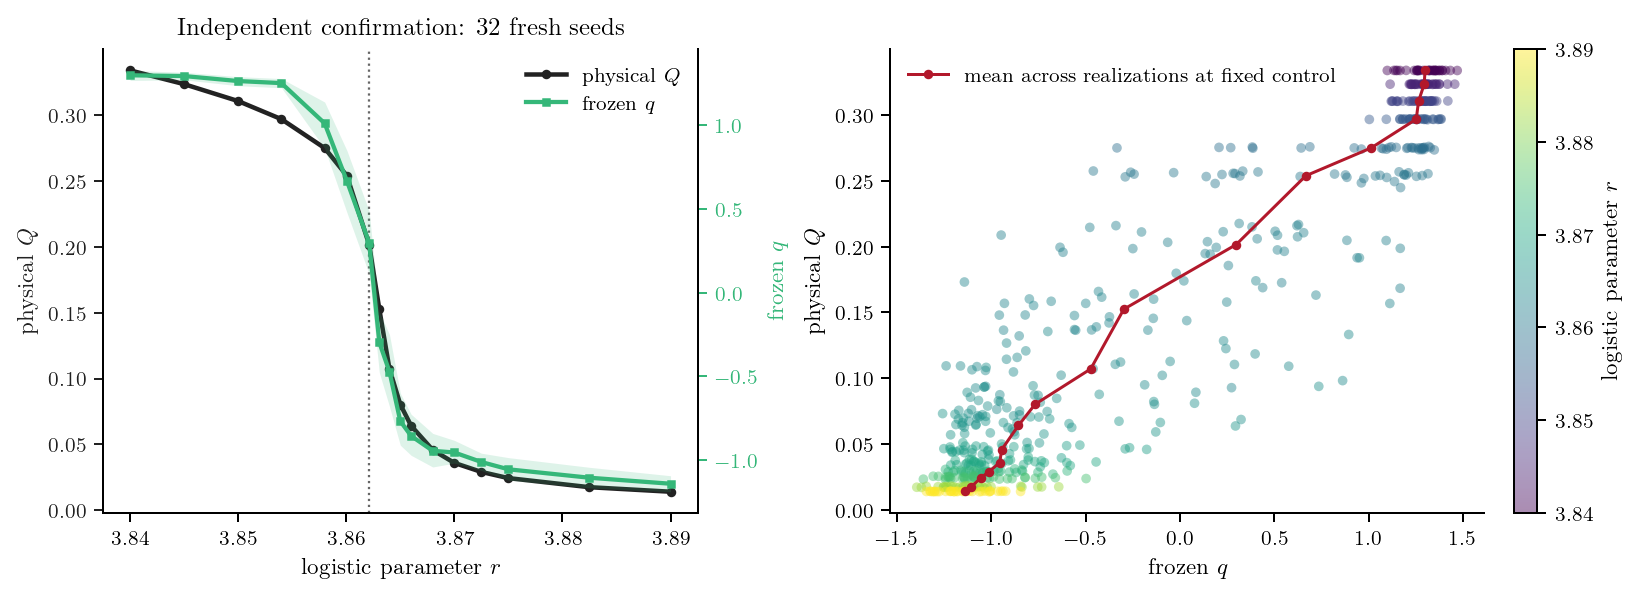

In [18]:
CML2D_CONFIRM_ROOT = ROOT / 'data/order_parameter/cml2d_confirmation_260911'
cml2d_confirm_reports = {}
for arm in ['primary', 'sensitivity']:
    path = CML2D_CONFIRM_ROOT / f'{arm}-analysis/confirmation-report.json'
    if path.exists():
        cml2d_confirm_reports[arm] = json.loads(path.read_text())
        pass
        pass
        pass
    else:
        pass
if 'primary' in cml2d_confirm_reports:
    cml2d_confirm_summary = json.loads((CML2D_CONFIRM_ROOT / 'primary-analysis/summary.json').read_text())
    cml2d_confirm_sign = cml2d_confirm_summary['display_sign']
    cml2d_confirm_all = pd.read_csv(CML2D_CONFIRM_ROOT / 'primary-analysis/scores.csv')
    cml2d_confirm = cml2d_confirm_all.query('eligible').copy()
    pass
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)
    dual_tracking(axes[0], cml2d_confirm, control='r', Q='Q_reference', q='q', q_sign=cml2d_confirm_sign, q_color=COLORS[32], boundary=3.86212, title='Independent confirmation: 32 fresh seeds')
    points = recovery_scatter(axes[1], cml2d_confirm, Q='Q_reference', q='q', control='r', q_sign=cml2d_confirm_sign)
    fig.colorbar(points, ax=axes[1], label=CONTROL_LABELS['r'])
    if not cml2d_confirm_reports['primary']['gate']['passes']:
        fig.suptitle('Quality gate failed: descriptive results only')
    plt.show()
    physics = pd.read_csv(CML2D_CONFIRM_ROOT / 'primary-analysis/physics-reference-audit.csv')
    pass
    pass

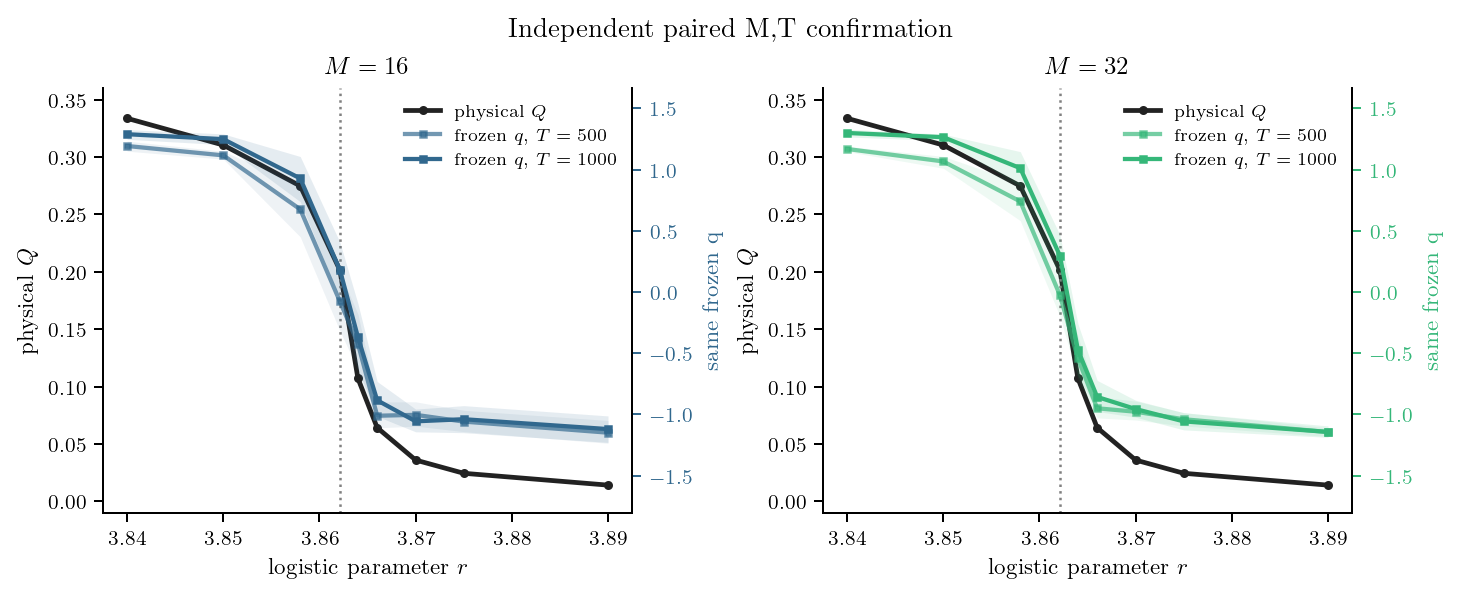

In [19]:
if {'primary', 'sensitivity'}.issubset(cml2d_confirm_reports):
    OLD_CONTROLS = np.sort(cml2d_scores.r.unique()).tolist()
    secondary = pd.read_csv(CML2D_CONFIRM_ROOT / 'sensitivity-analysis/scores.csv')
    primary_old = cml2d_confirm_all[cml2d_confirm_all.r.isin(OLD_CONTROLS)]
    views = pd.concat([primary_old, secondary], ignore_index=True).query('eligible').copy()
    paired = secondary.query('eligible').merge(primary_old.query('eligible')[['seed', 'r', 'q']].rename(columns={'q': 'q_primary'}), on=['seed', 'r'], validate='many_to_one')
    agreement = []
    for (M, T), part in paired.groupby(['M', 'T']):
        shift = cml2d_confirm_sign * (part.q - part.q_primary)
        agreement.append(dict(M=M, T=T, paired_rows=len(part), rho_with_primary=spearman(part.q, part.q_primary), mean_shift=shift.mean(), median_absolute_difference=np.median(abs(shift))))
    pass
    pass
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.2), constrained_layout=True)
    limits = (cml2d_confirm_sign * views.q).agg(['min', 'max']).to_numpy()
    pad = max(0.1, 0.05 * np.ptp(limits))
    for ax, M in zip(axes, [16, 32]):
        right = ax.twinx()
        truth = bootstrap_curve(primary_old.query('eligible'), 'r', 'Q_reference', seed=260911)
        line, = ax.plot(truth.r, truth['mean'], color=Q_COLOR, marker='o', ms=2.6, lw=1.9, label='physical $Q$')
        ax.fill_between(truth.r, truth.lower, truth.upper, color=Q_FILL, alpha=0.16, linewidth=0)
        lines = [line]
        for T in [500, 1000]:
            part = views.query('M == @M and T == @T')
            curve = bootstrap_curve(part.assign(display_q=cml2d_confirm_sign * part.q), 'r', 'display_q', seed=260911)
            curve = curve.set_index('r').reindex(OLD_CONTROLS).reset_index()
            line, = right.plot(curve.r, curve['mean'], color=COLORS[M], alpha=T_ALPHA[T], marker='s', ms=2.4, lw=1.7, label=f'frozen $q$, $T={T}$')
            right.fill_between(curve.r, curve.lower, curve.upper, color=COLORS[M], alpha=0.12 * T_ALPHA[T], linewidth=0)
            lines.append(line)
        ax.axvline(3.86212, color='.5', ls=':', lw=1)
        ax.set(xlabel=CONTROL_LABELS['r'], ylabel='physical $Q$', title=f'$M={M}$', ylim=(-0.01, 0.36))
        right.set(ylabel='same frozen q', ylim=(limits[0] - pad, limits[1] + pad))
        right.yaxis.label.set_color(COLORS[M])
        right.tick_params(axis='y', colors=COLORS[M])
        ax.legend(lines, [line.get_label() for line in lines], frameon=False, fontsize=7)
        paper_axis(ax)
        paper_axis(right, right=True)
    passed = all((report['gate']['passes'] for report in cml2d_confirm_reports.values()))
    fig.suptitle('Independent paired M,T confirmation' + ('' if passed else ' — failed arm is descriptive only'))
    plt.show()
    audit = CML2D_CONFIRM_ROOT / 'integrity-audit.json'
    if audit.exists():
        pass
        pass

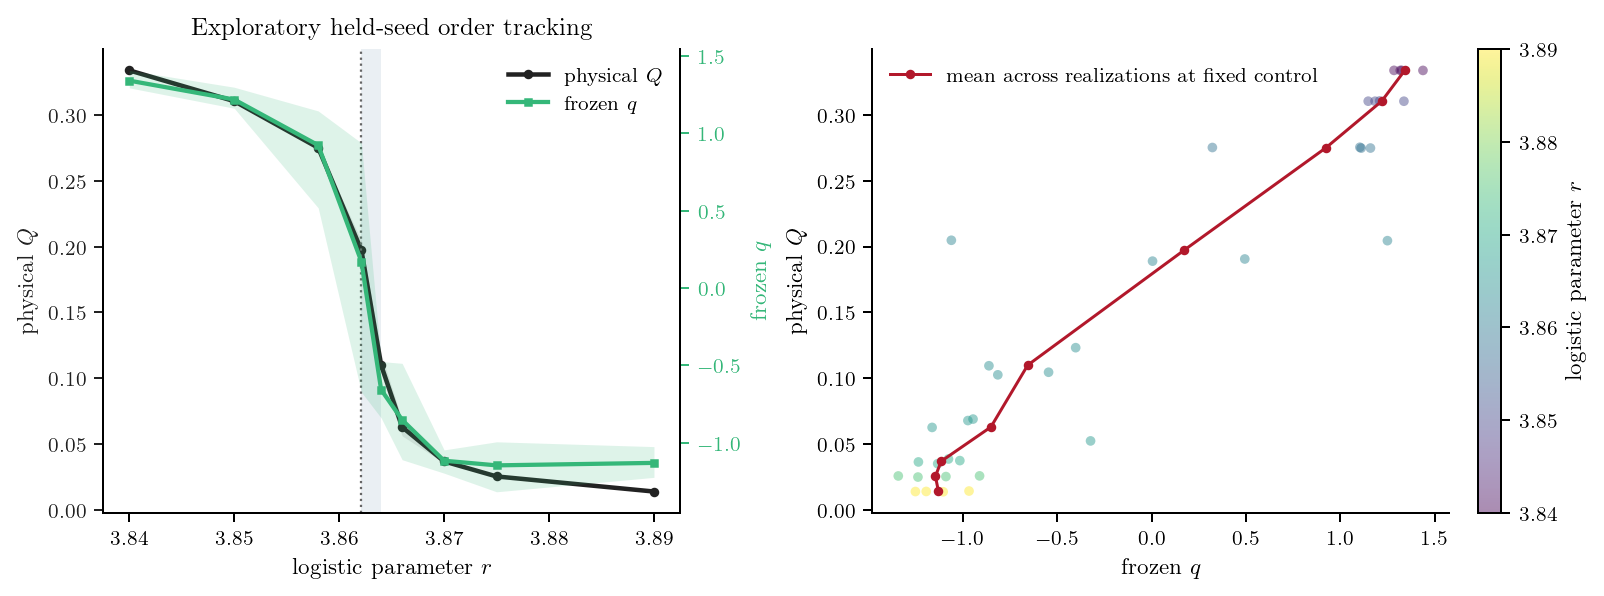

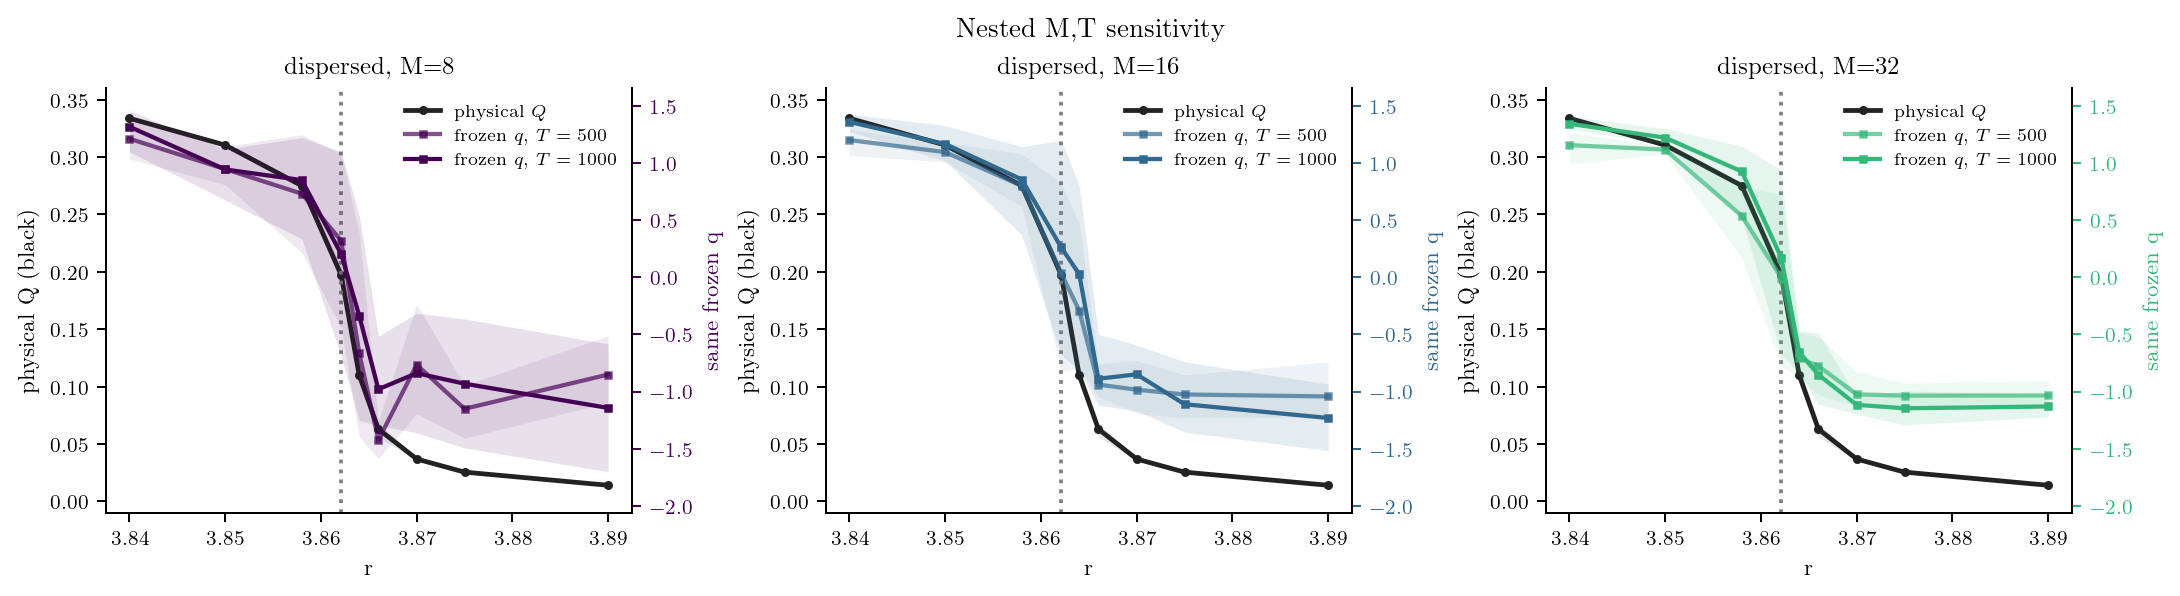

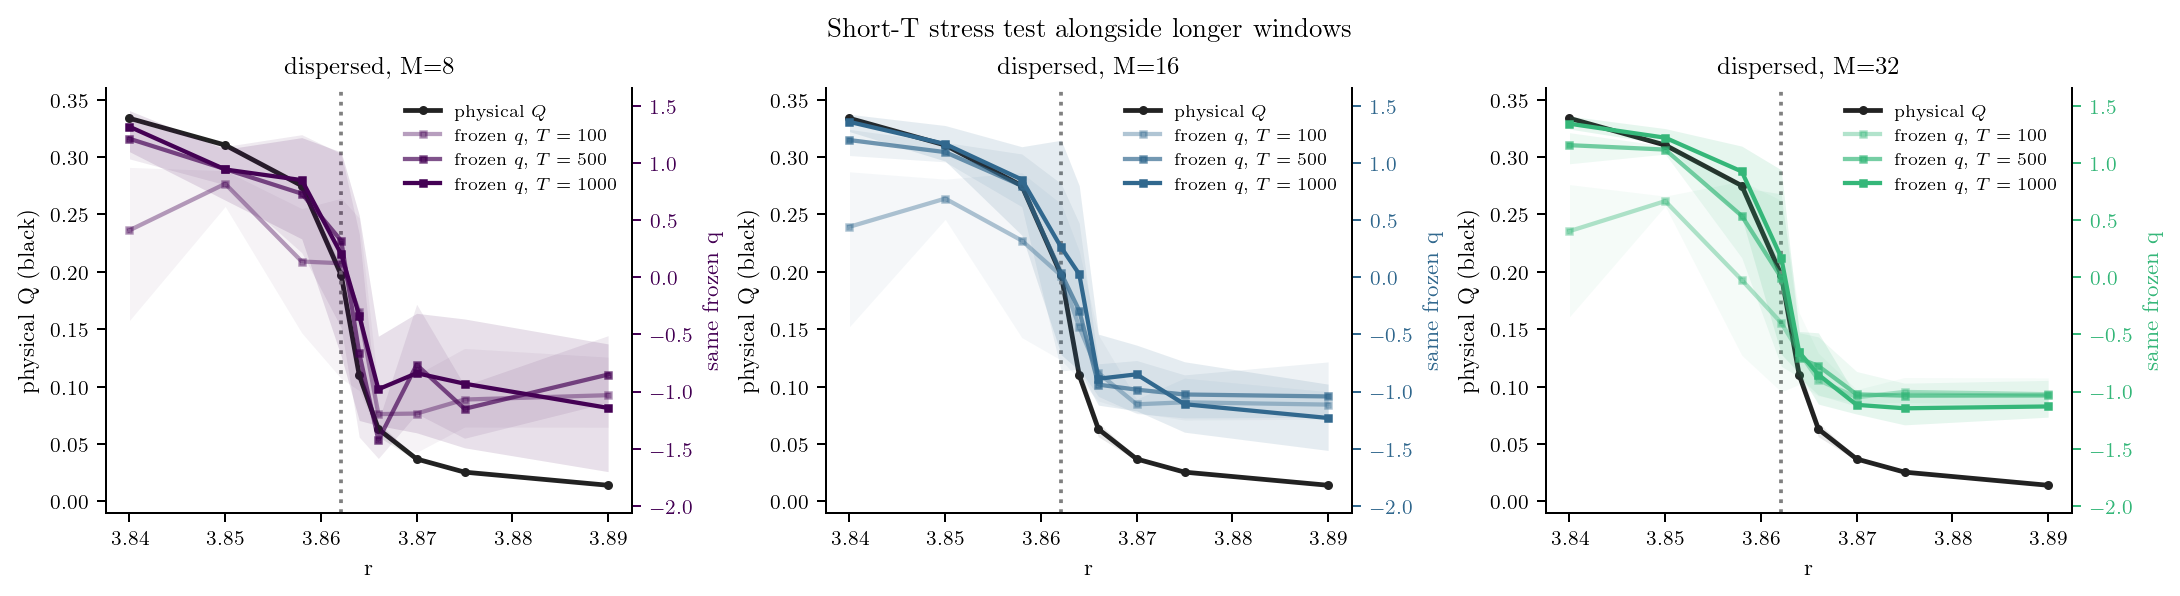

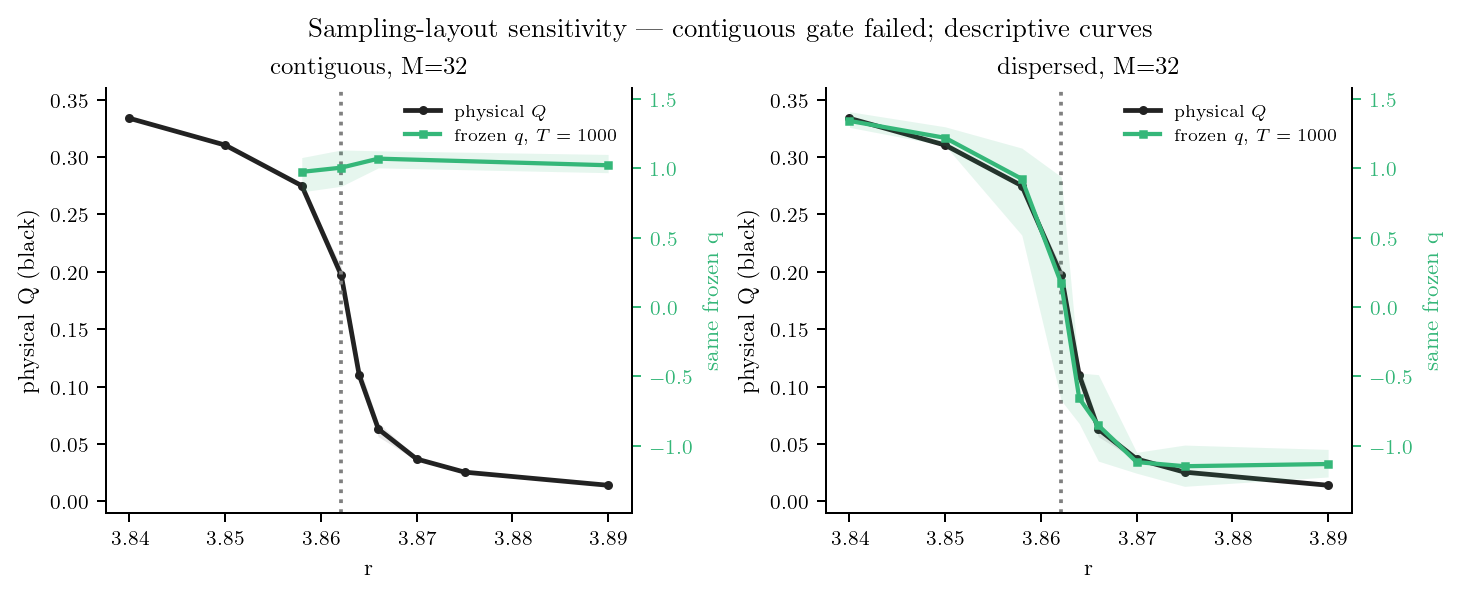

In [20]:
CML2D_SPI = CML2D_ROOT / 'primary-analysis'
if not (CML2D_SPI / 'summary.json').exists():
    pass
else:
    cml2d_spi_summary = json.loads((CML2D_SPI / 'summary.json').read_text())
    pass
    pass
    pass
    cml2d_scores = pd.read_csv(CML2D_SPI / 'scores.csv')
    cml2d_fit = cml2d_scores.query("role == 'development' and eligible")
    cml2d_sign = -1 if spearman(cml2d_fit.q, cml2d_fit.Q_reference) < 0 else 1
    cml2d_held = cml2d_scores.query("role == 'evaluation' and eligible").copy()
    from src.order_parameter_analysis import clustered_bootstrap_spearman
    if cml2d_held.seed.nunique() >= 2:
        uncertainty = []
        for target in ['Q_reference', 'Q_window']:
            overall, within = clustered_bootstrap_spearman(cml2d_sign * cml2d_held.q, cml2d_held[target], cml2d_held.r, cml2d_held.seed, n_resamples=2000, seed=260911)
            residual = cml2d_held[['q', target]] - cml2d_held.groupby('r')[['q', target]].transform('mean')
            uncertainty.append({'target': target, 'overall rho': spearman(cml2d_sign * cml2d_held.q, cml2d_held[target]), 'overall 95% interval': np.nanquantile(overall, [0.025, 0.975]).round(4).tolist(), 'within r rho': spearman(cml2d_sign * residual.q, residual[target]), 'within r 95% interval': np.nanquantile(within, [0.025, 0.975]).round(4).tolist()})
        pass
        pass
        pass
    fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.2), constrained_layout=True)
    dual_tracking(axes[0], cml2d_held, control='r', Q='Q_reference', q='q', q_sign=cml2d_sign, q_color=COLORS[32], boundary=3.86212, title='Exploratory held-seed order tracking')
    intervals = cml2d_spi_summary['results'][0]['steepest_intervals']
    if intervals['q'] == intervals['Q_reference']:
        axes[0].axvspan(*intervals['q'], color='#31688e', alpha=0.1, lw=0)
        pass
    points = recovery_scatter(axes[1], cml2d_held, Q='Q_reference', q='q', control='r', q_sign=cml2d_sign)
    fig.colorbar(points, ax=axes[1], label=CONTROL_LABELS['r'])
    plt.show()
    cml2d_banks = [cml2d_scores]
    for name in ['sensitivity-analysis', 'short-T-analysis', 'contiguous-analysis']:
        if (CML2D_ROOT / name / 'summary.json').exists():
            result = json.loads((CML2D_ROOT / name / 'summary.json').read_text())
            pass
            pass
            scores = pd.read_csv(CML2D_ROOT / name / 'scores.csv')
            pass
            paired = scores.query("role == 'evaluation' and eligible").merge(cml2d_held[['seed', 'r', 'q']].rename(columns={'q': 'q_primary'}), on=['seed', 'r'], validate='many_to_one')
            agreement = []
            for (view, M, T), part in paired.groupby(['view', 'M', 'T']):
                difference = cml2d_sign * (part.q - part.q_primary)
                agreement.append({'view': view, 'M': M, 'T': T, 'paired rows': len(part), 'rho with primary q': spearman(part.q, part.q_primary), 'mean q shift': difference.mean(), 'median abs q difference': np.median(abs(difference))})
            pass
            pass
            cml2d_banks.append(scores)
            scores = pd.concat(cml2d_banks, ignore_index=True).drop_duplicates(['seed', 'r', 'view', 'M', 'T'])
            plotted = scores.query("role == 'evaluation' and eligible").copy()
            if name == 'contiguous-analysis':
                plotted = plotted.query('M == 32 and T == 1000')
            if plotted.empty:
                pass
                continue
            groups = list(plotted.groupby(['view', 'M']))
            qlo, qhi = (cml2d_sign * plotted.q).agg(['min', 'max'])
            padding = max(0.1, 0.05 * (qhi - qlo))
            fig, axes = plt.subplots(1, len(groups), figsize=(4 * len(groups), 3.2), squeeze=False, constrained_layout=True)
            for ax, ((view, M), group) in zip(axes.flat, groups):
                right = ax.twinx()
                reference = cml2d_held.groupby('r').Q_reference.mean()
                line_Q, = ax.plot(reference.index, reference, color=Q_COLOR, lw=1.9, marker='o', ms=2.6, label='physical $Q$')
                reference_band = bootstrap_curve(cml2d_held, 'r', 'Q_reference', seed=260911)
                ax.fill_between(reference_band.r, reference_band.lower, reference_band.upper, color=Q_FILL, alpha=0.16, linewidth=0)
                lines = [line_Q]
                for T, part in group.groupby('T'):
                    curve = bootstrap_curve(part.assign(display_q=cml2d_sign * part.q), 'r', 'display_q', seed=260911)
                    expected = np.sort(scores.loc[(scores['view'] == view) & (scores['M'] == M) & (scores['T'] == T), 'r'].unique())
                    curve = curve.set_index('r').reindex(expected)
                    counts = part.groupby('r').size().reindex(expected, fill_value=0)
                    curve.loc[counts < 2, ['lower', 'upper']] = np.nan
                    curve = curve.reset_index()
                    line_q, = right.plot(curve.r, curve['mean'], marker='s', lw=1.7, ms=2.4, label=f'frozen $q$, $T={T}$', color=COLORS[M], alpha=T_ALPHA[T])
                    lines.append(line_q)
                    right.fill_between(curve.r, curve.lower, curve.upper, color=COLORS[M], alpha=0.12 * T_ALPHA[T], linewidth=0)
                ax.axvline(3.86212, color='.5', ls=':')
                ax.set(xlabel='r', ylabel='physical Q (black)', title=f'{view}, M={M}')
                right.set_ylabel('same frozen q', color=COLORS[M])
                right.tick_params(axis='y', colors=COLORS[M])
                ax.set_ylim(-0.01, 0.36)
                right.set_ylim(qlo - padding, qhi + padding)
                ax.legend(lines, [line.get_label() for line in lines], frameon=False, fontsize=7)
                paper_axis(ax)
                paper_axis(right, right=True)
            title = {'sensitivity-analysis': 'Nested M,T sensitivity', 'short-T-analysis': 'Short-T stress test alongside longer windows', 'contiguous-analysis': 'Sampling-layout sensitivity'}[name]
            failure = ' — contiguous gate failed; descriptive curves' if name == 'contiguous-analysis' else ' — joint row gate failed; descriptive curves'
            fig.suptitle(title + ('' if result['passes_row_gate'] else failure))
            plt.show()

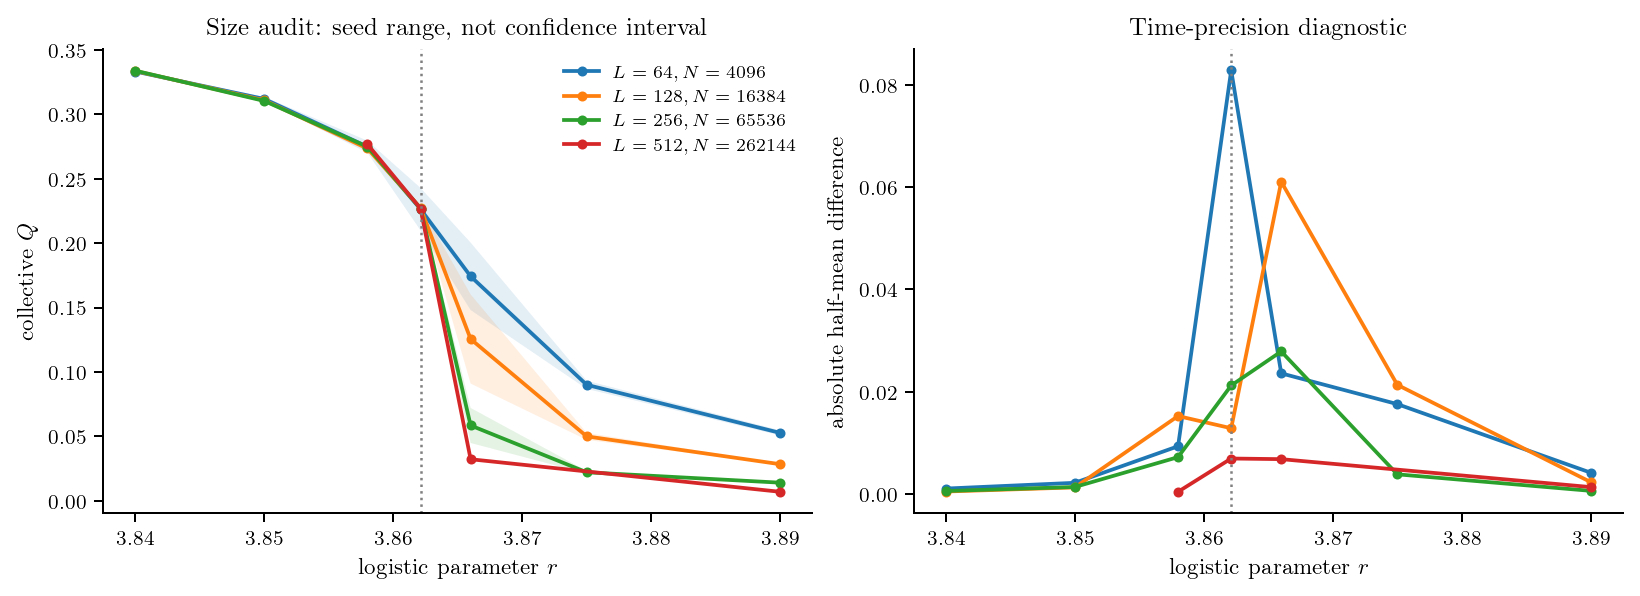

In [21]:
CML2D_ROOT = ROOT / 'data/order_parameter/cml2d_period_doubling_260911'
cml2d_physics = pd.read_csv(CML2D_ROOT / 'physics-analysis/physics.csv')
cml2d_sizes = cml2d_physics.copy()
if (CML2D_ROOT / 'convergence-analysis/physics.csv').exists():
    cml2d_convergence = pd.read_csv(CML2D_ROOT / 'convergence-analysis/physics.csv')
    cml2d_sizes = pd.concat([cml2d_sizes, cml2d_convergence.query('burn == 20000 and record_steps == 42000')])
pass
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)
for L, group in cml2d_sizes.groupby('L'):
    curve = group.groupby('r').agg(Q=('Q', 'mean'), lo=('Q', 'min'), hi=('Q', 'max'), drift=('half_difference', 'max'))
    axes[0].plot(curve.index, curve.Q, 'o-', ms=3, label=f'$L={L}, N={L * L}$')
    axes[0].fill_between(curve.index, curve.lo, curve.hi, alpha=0.12)
    axes[1].plot(curve.index, curve.drift, 'o-', ms=3)
for ax in axes:
    ax.axvline(3.86212, color='.5', ls=':', lw=1)
    ax.set_xlabel('logistic parameter $r$')
    paper_axis(ax)
axes[0].set(ylabel='collective $Q$', title='Size audit: seed range, not confidence interval')
axes[0].legend(frameon=False, fontsize=7)
axes[1].set(ylabel='absolute half-mean difference', title='Time-precision diagnostic')
plt.show()
if (CML2D_ROOT / 'convergence-analysis/physics.csv').exists():
    cml2d_convergence = pd.read_csv(CML2D_ROOT / 'convergence-analysis/physics.csv')
    pass
if (CML2D_ROOT / 'primary-physics/physics.csv').exists():
    cml2d_primary_physics = pd.read_csv(CML2D_ROOT / 'primary-physics/physics.csv')
    pass
    pass
    pass
    raw = pd.read_csv(CML2D_ROOT / 'primary-physics/observations.csv').merge(cml2d_primary_physics[['path', 'Q']], on='path', validate='many_to_one')
    raw_rows = []
    for (view, M), group in raw.query('seed >= 26091115 and T == 1000').groupby(['view', 'M']):
        raw_rows.append({'view': view, 'M': M, 'sampled Q vs future Q': spearman(group.sample_Q, group.Q), 'mean absolute correlation vs future Q': spearman(group.mean_abs_correlation, group.Q)})
    pass
    pass
    pass

### Three-control composite

<!-- The top row is the global-mean time trace, not $Q$. The lattice images are later saved fields at the same control and seed, not the exact first 100 displayed steps. The bottom row is the independent across-control confirmation. Changing $M$ or $T$ can shift $q$; no exact invariance or arbitrary-patch transfer is claimed. -->

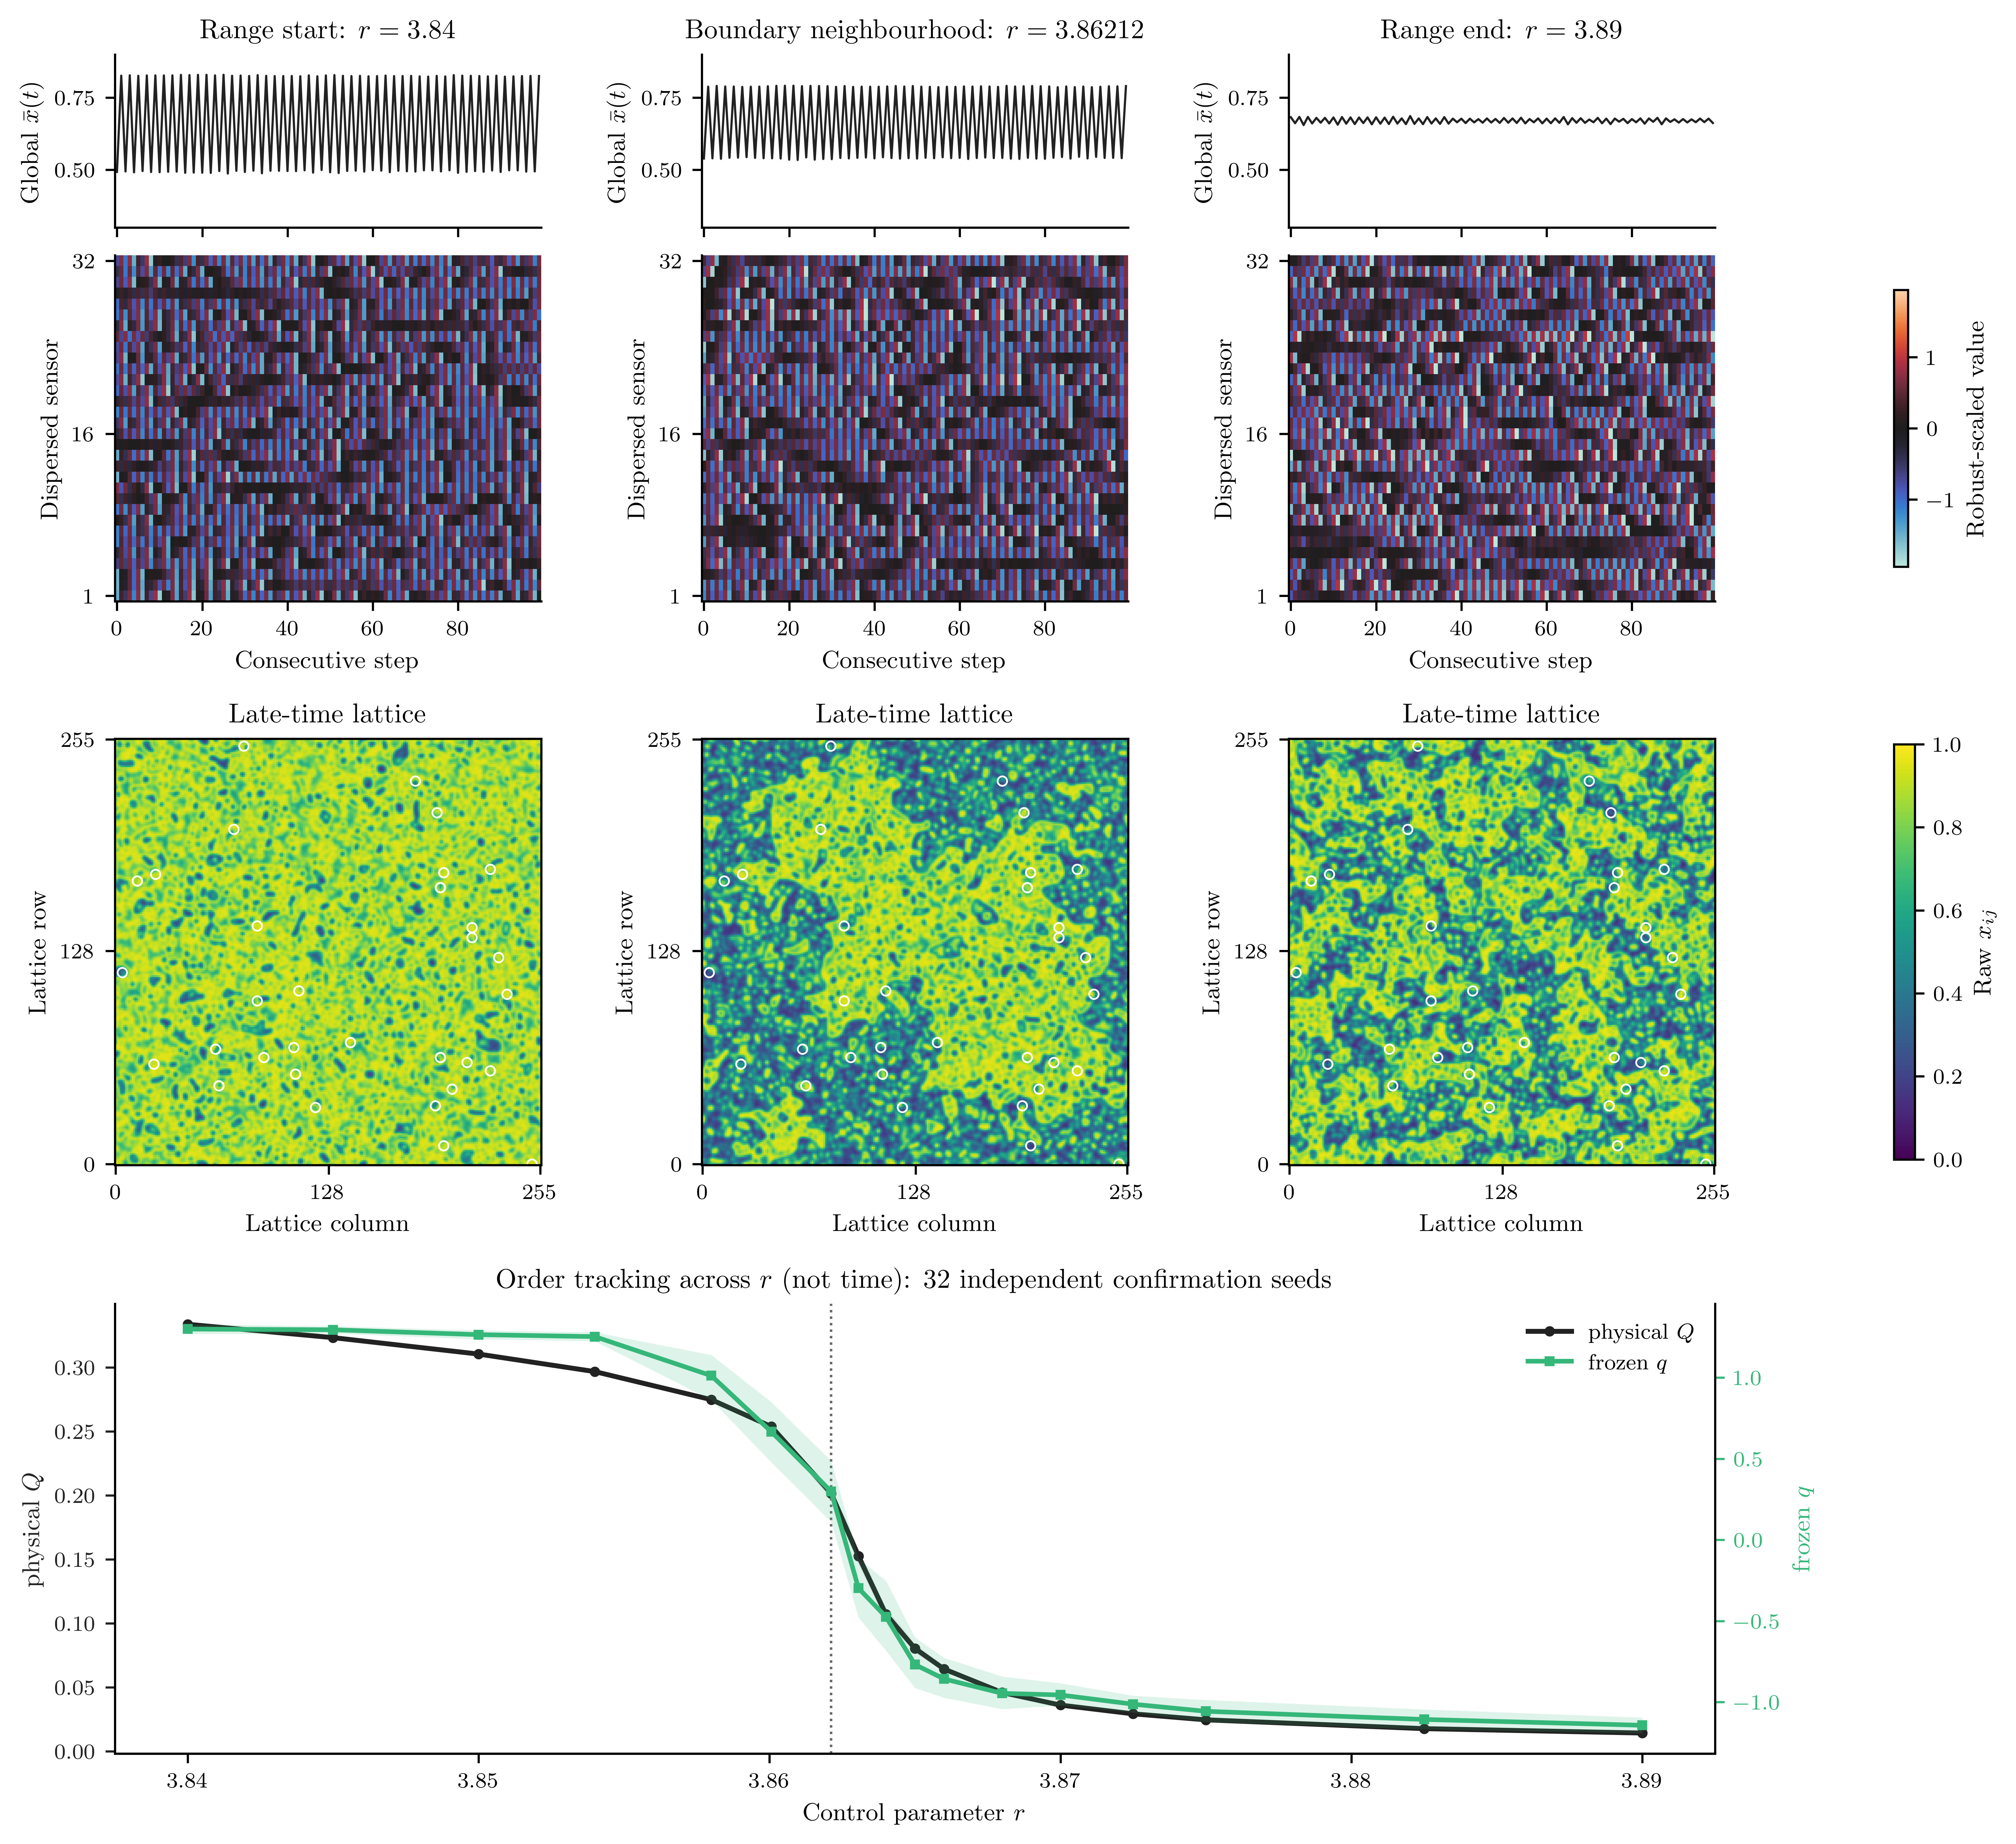

In [22]:
cml2d_preview_root = ROOT / 'data/order_parameter/cml2d_confirmation_260911/primary-analysis'
cml2d_preview_frame = pd.read_csv(cml2d_preview_root / 'scores.csv').query('eligible')
cml2d_preview_sign = json.loads((cml2d_preview_root / 'summary.json').read_text())['display_sign']

def cml2d_preview_tracking(ax):
    dual_tracking(ax, cml2d_preview_frame, control='r', Q='Q_reference', q='q', q_sign=cml2d_preview_sign, q_color=COLORS[32], boundary=3.86212, title='Order tracking across $r$ (not time): 32 independent confirmation seeds')
    ax.set_xlabel('Control parameter $r$')
cml2d_preview_path = export_snapshots(CML2D_ROOT, cml2d_snapshot_dir, tracking_panel=cml2d_preview_tracking)
display(Image(filename=str(cml2d_preview_path)))

### Full small lattices: diagnostic failures, not successful inference

$L=6$ gives $M=N=36$; $L=8$ gives $M=N=64$. Both use the same 17 controls, $T=1000$, eight development and 32 held seeds, and the same burn/reference lengths. $L=6$ retains all rows but its fitted PC1 fails seed-stability; plotted $q$ is **descriptive only**. $L=8$ has constant-channel records and stopped before p90. Grey MTS rows mask numerical constancy. These finite lattices often settle onto periodic attractors, so they are not small replicas of the large-lattice chaotic transition.

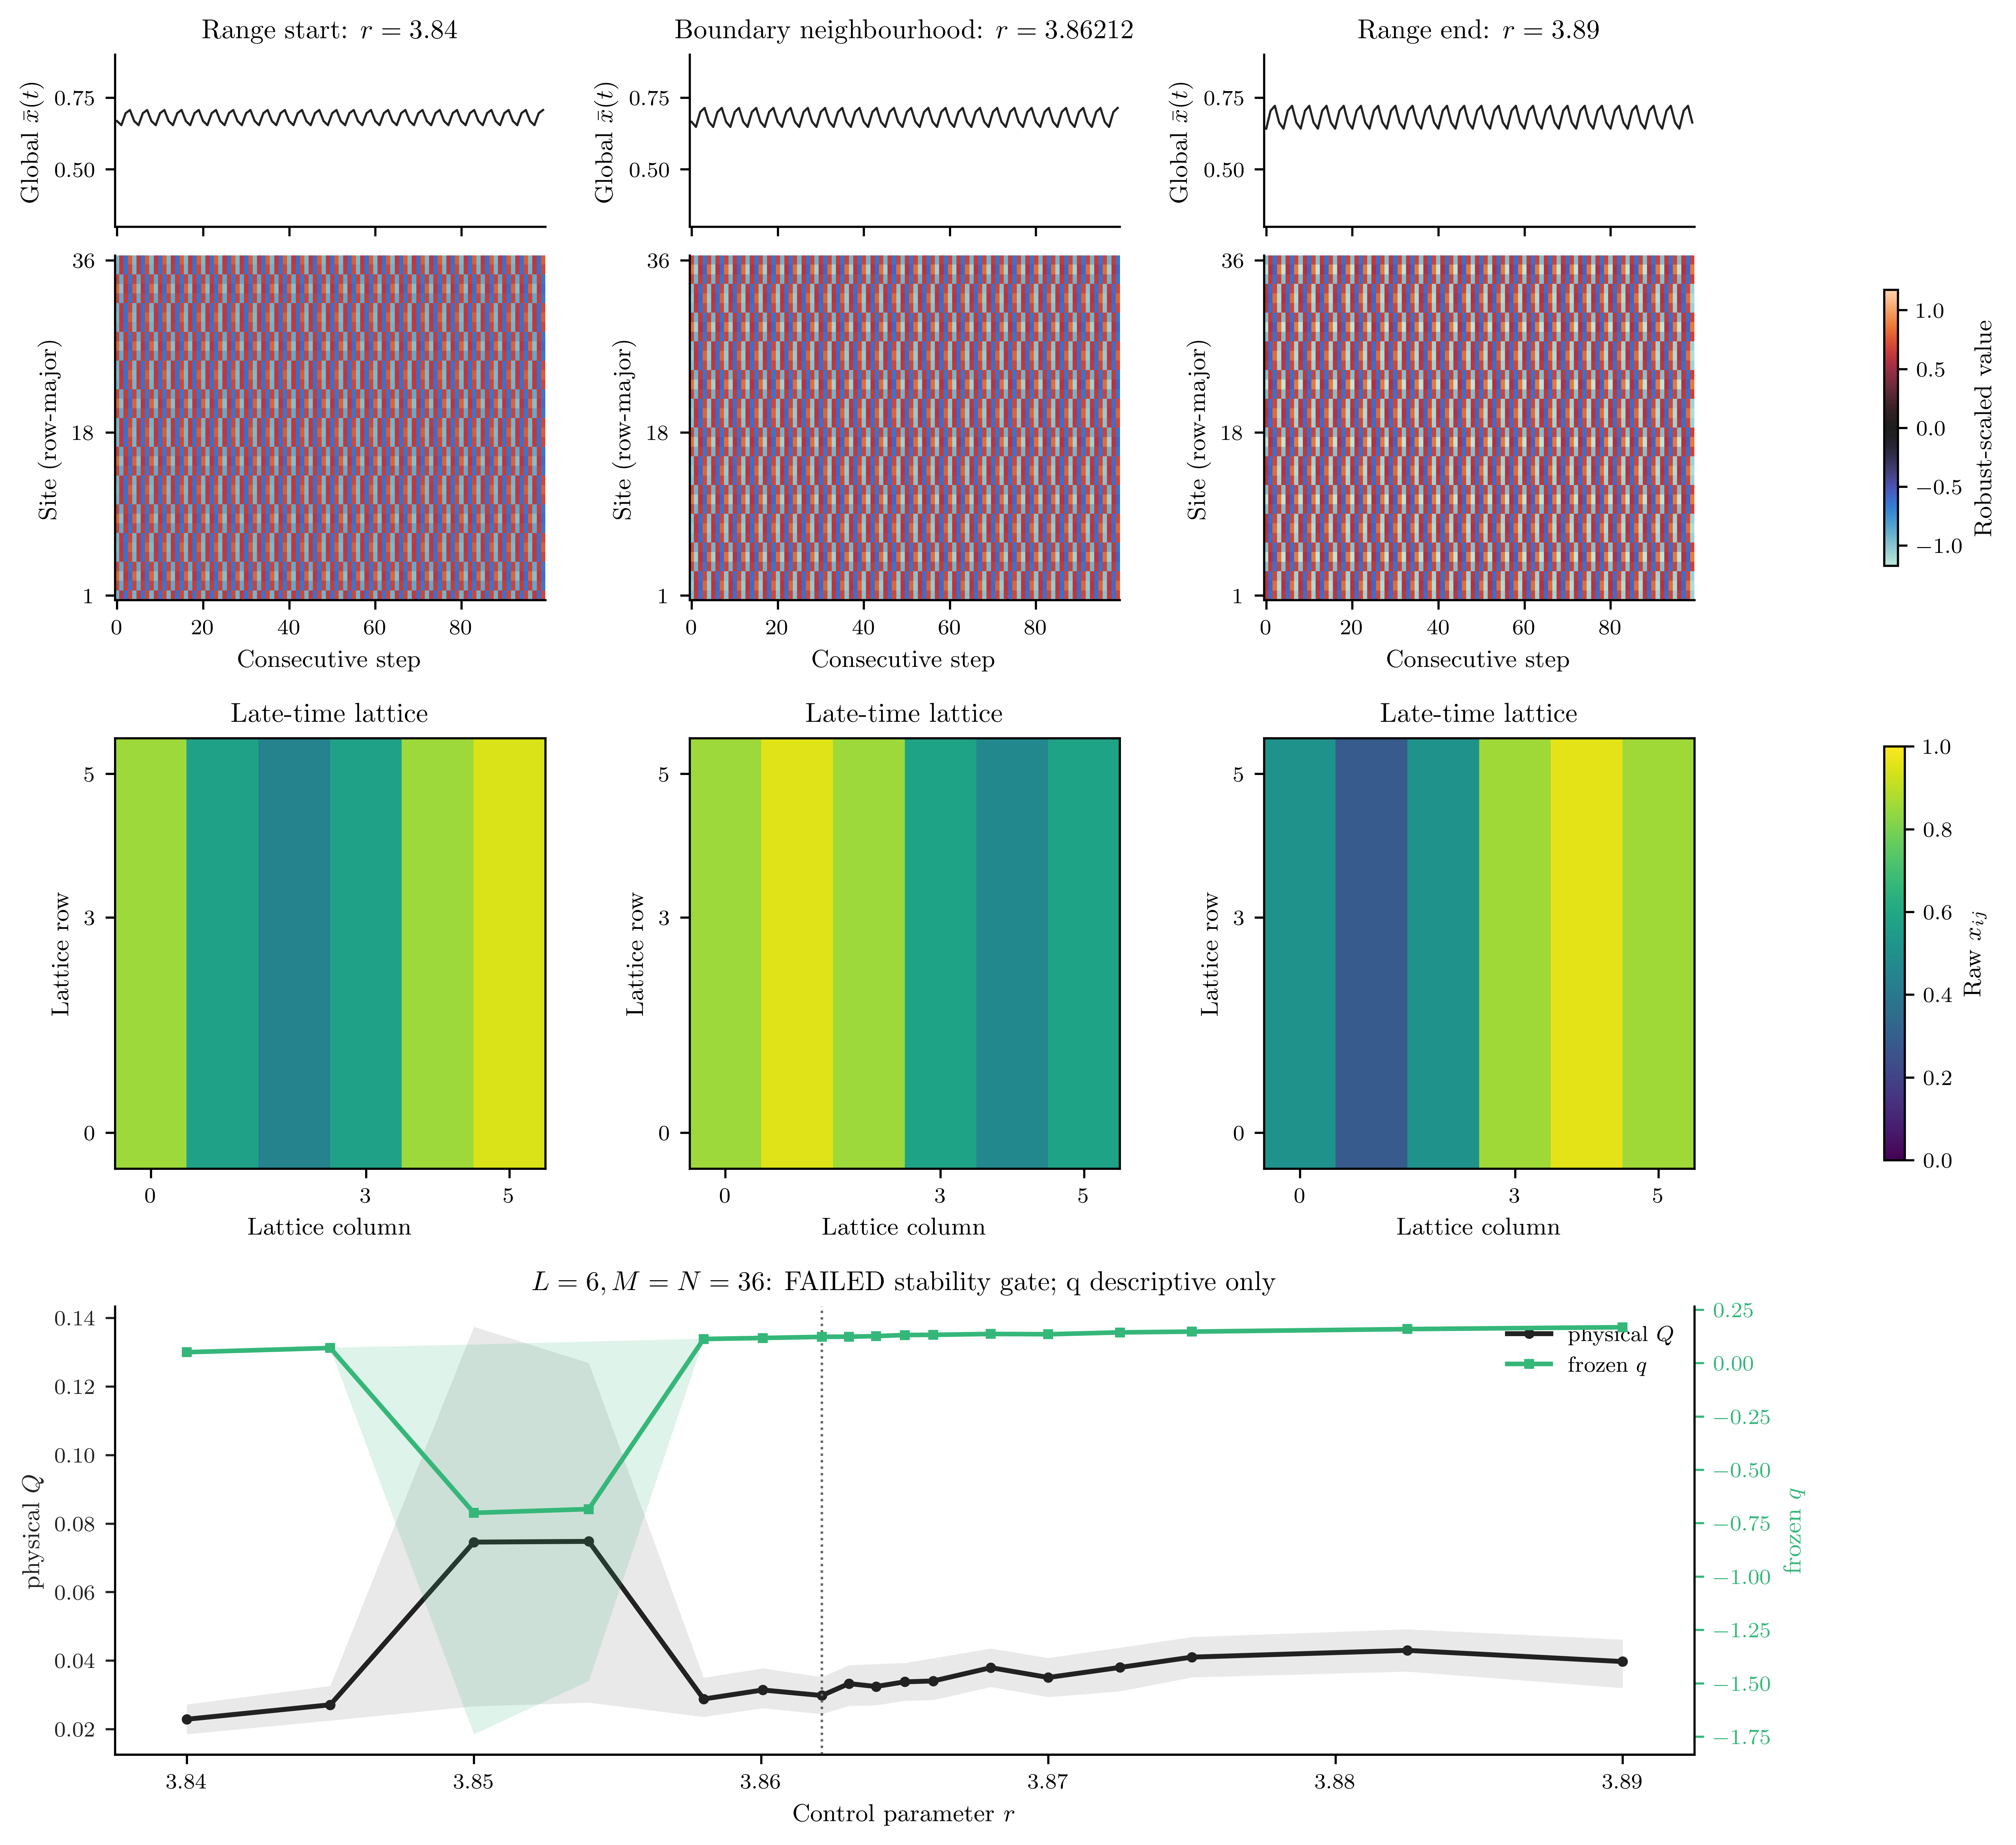

In [23]:
small_L = 6
small_root = ROOT / 'data/order_parameter/cml2d_full_observation_260914' / f'L{small_L}'
small_report_path = small_root / 'analysis/diagnostic-report.json'
if not (small_root / 'physics.csv').exists():
    pass
else:
    small_physics = pd.read_csv(small_root / 'physics.csv').query('seed >= 260914101')
    pass
    raw_failures = small_physics.minimum_channel_sd.le(1e-08)
    pass
    small_report = json.loads(small_report_path.read_text()) if small_report_path.exists() else None
    has_q = small_report is not None and small_report['gate']['passes']
    if small_report is not None:
        pass
    else:
        pass
    show_descriptive_q = small_report is not None and (small_root / 'analysis/scores.csv').exists()
    if show_descriptive_q:
        small_summary = json.loads((small_root / 'analysis/summary.json').read_text())
        small_held = pd.read_csv(small_root / 'analysis/scores.csv').query("role == 'evaluation' and eligible")
        show_descriptive_q = len(small_held) > 0

    def small_tracking_panel(ax):
        if show_descriptive_q:
            verdict = 'held-out small-system inference' if has_q else 'FAILED stability gate; q descriptive only'
            dual_tracking(ax, small_held, control='r', Q='Q_reference', q='q', q_sign=small_summary['display_sign'], q_color=COLORS[32], boundary=3.86212, title=f'$L={small_L}, M=N={small_L ** 2}$: {verdict}')
        else:
            curve = bootstrap_curve(small_physics, 'r', 'Q')
            ax.plot(curve.r, curve['mean'], 'o-', color=Q_COLOR, ms=3)
            ax.fill_between(curve.r, curve.lower, curve.upper, color=Q_FILL, alpha=0.16)
            ax.axvline(3.86212, color='.5', ls=':')
            state = 'raw-input gate stopped p90' if raw_failures.any() else 'p90 pending' if small_report is None else 'SPI–SPI gate failed'
            ax.set(ylabel='physical Q', title=f'L={small_L}: {state}; physical order only (32 evaluation seeds)')
            paper_axis(ax)
        ax.set_xlabel('Control parameter $r$')
    small_figure_dir = ROOT / 'notebooks/inference/figures/lean/cml2d-period-doubling' / f'L{small_L}-full'
    small_figure = export_snapshots(small_root, small_figure_dir, tracking_panel=small_tracking_panel, seed=260914101, M=small_L ** 2, full=True)
    display(Image(filename=str(small_figure)))
    transfer_path = small_root / 'transfer-analysis/diagnostic-report.json'
    if transfer_path.exists():
        pass
        pass

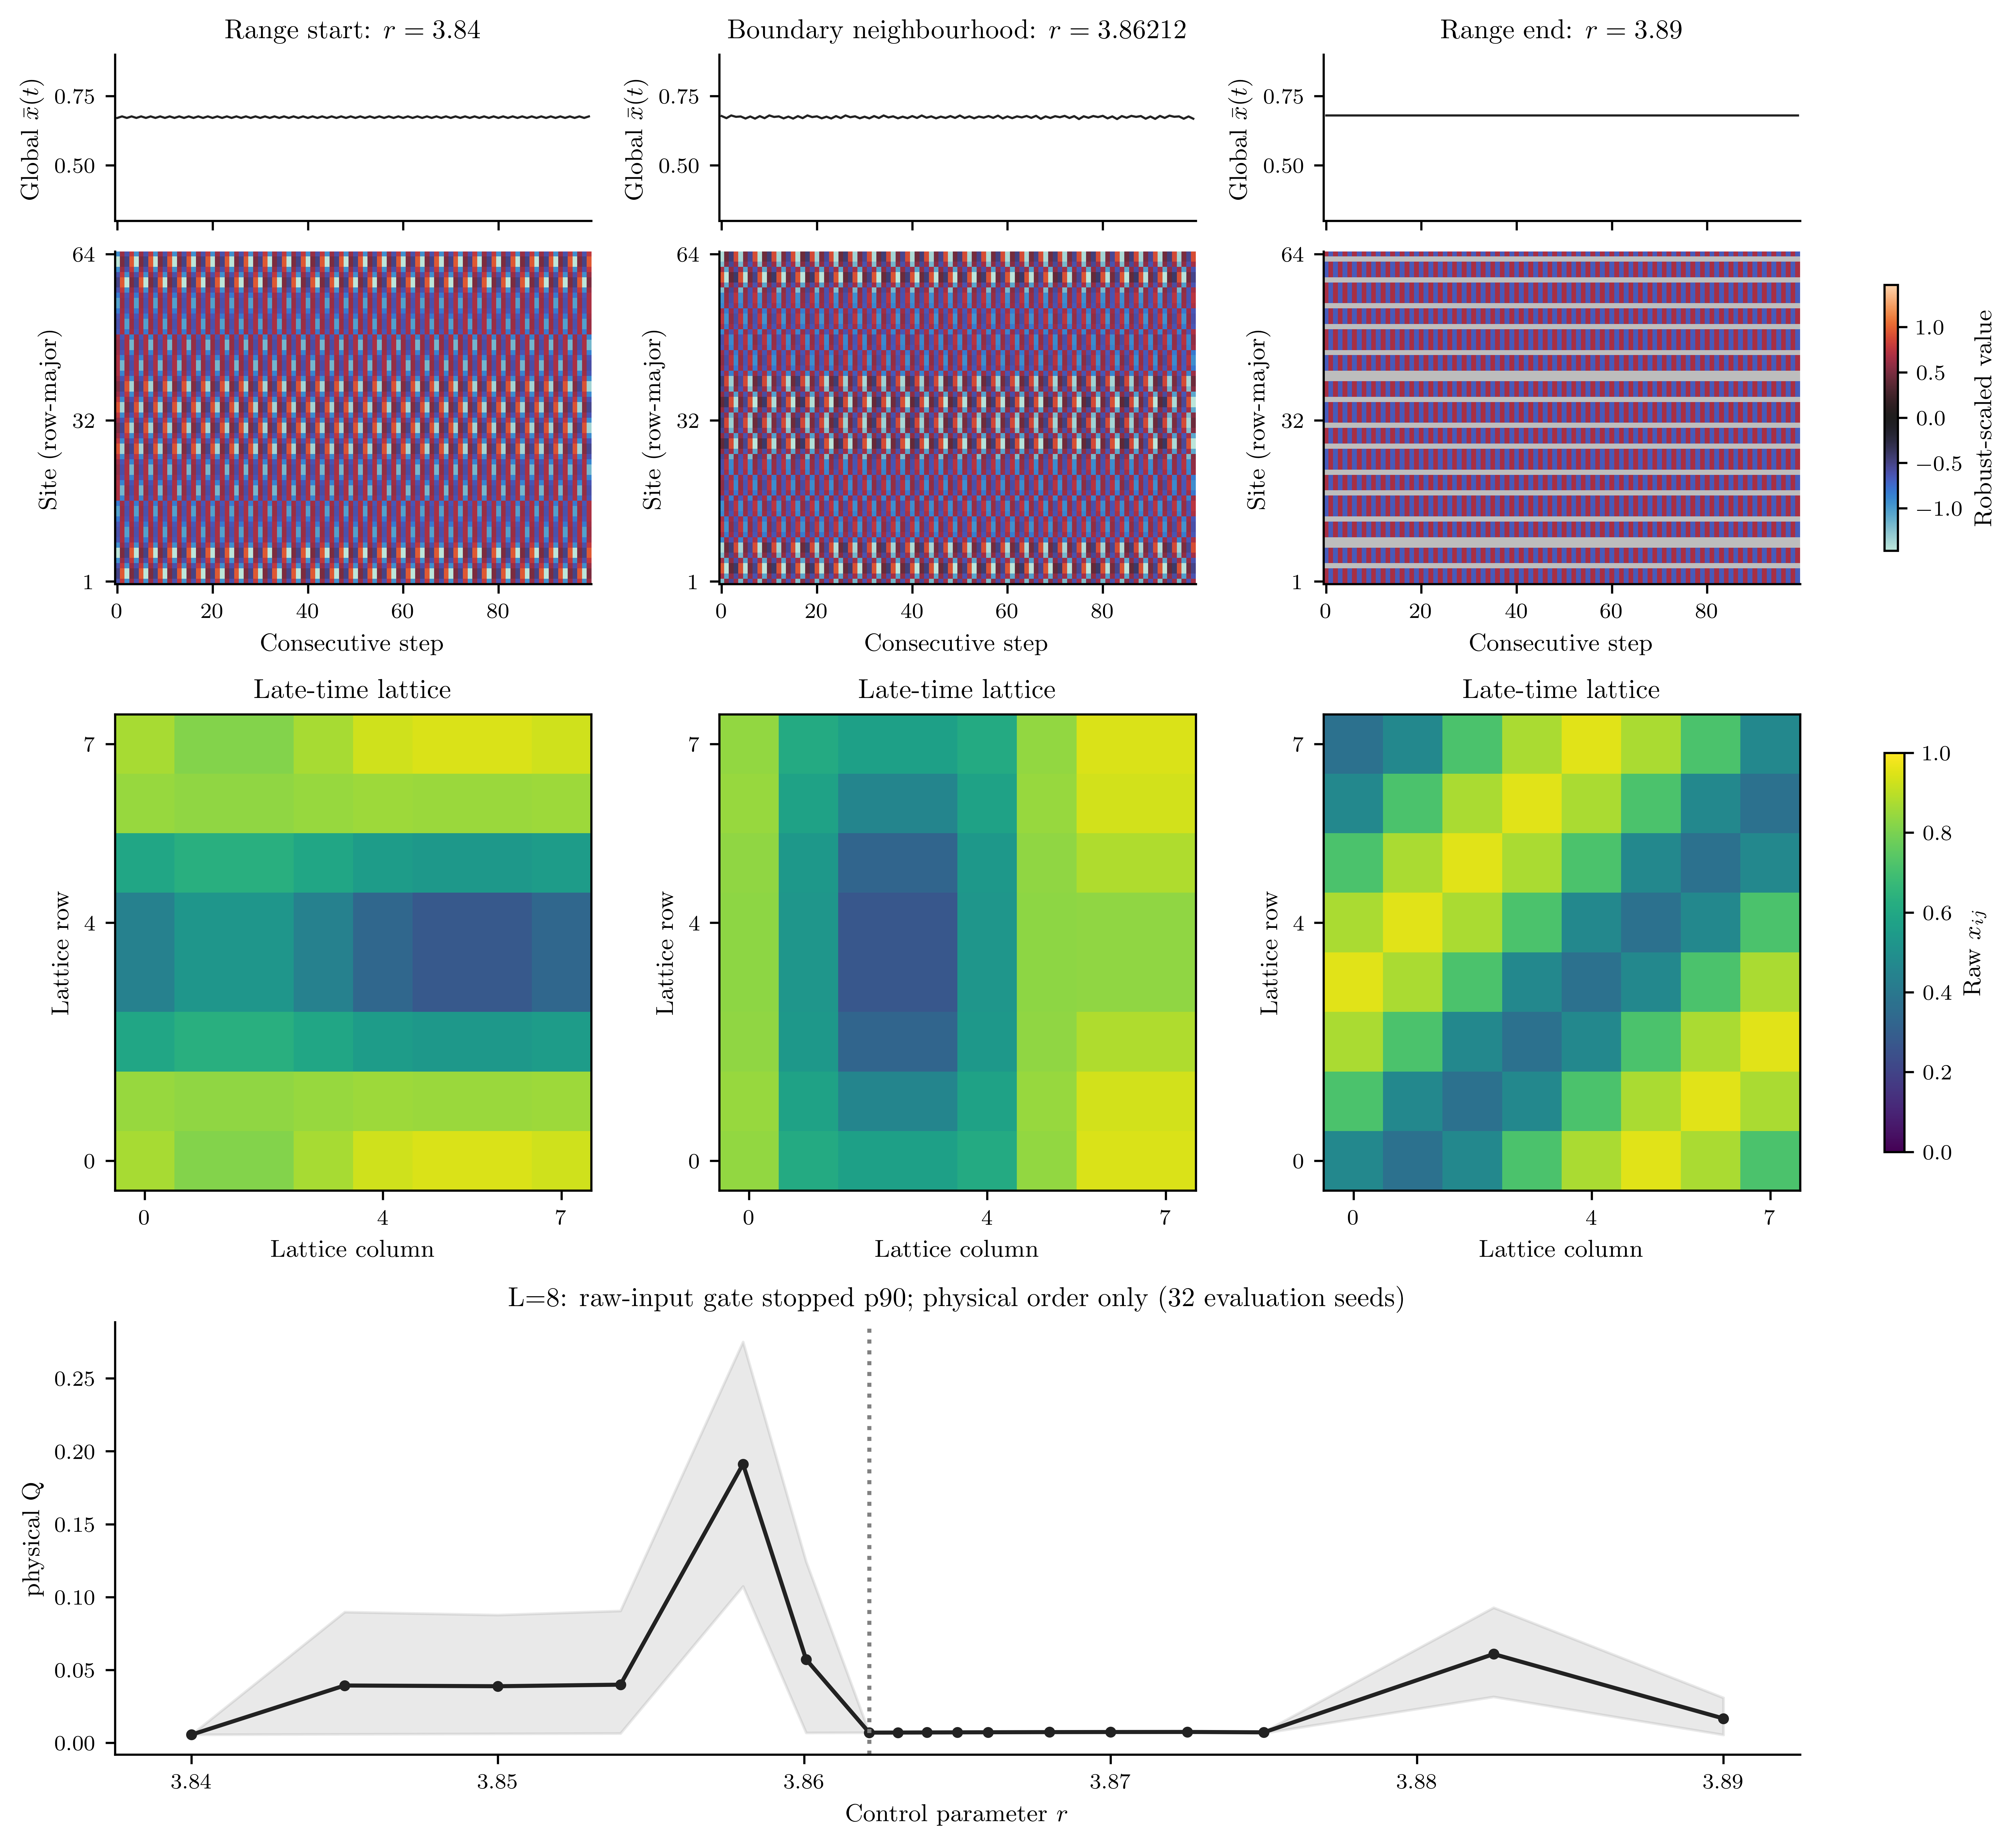

In [24]:
small_L = 8
small_root = ROOT / 'data/order_parameter/cml2d_full_observation_260914' / f'L{small_L}'
small_report_path = small_root / 'analysis/diagnostic-report.json'
if not (small_root / 'physics.csv').exists():
    pass
else:
    small_physics = pd.read_csv(small_root / 'physics.csv').query('seed >= 260914101')
    pass
    raw_failures = small_physics.minimum_channel_sd.le(1e-08)
    pass
    small_report = json.loads(small_report_path.read_text()) if small_report_path.exists() else None
    has_q = small_report is not None and small_report['gate']['passes']
    if small_report is not None:
        pass
    else:
        pass
    show_descriptive_q = small_report is not None and (small_root / 'analysis/scores.csv').exists()
    if show_descriptive_q:
        small_summary = json.loads((small_root / 'analysis/summary.json').read_text())
        small_held = pd.read_csv(small_root / 'analysis/scores.csv').query("role == 'evaluation' and eligible")
        show_descriptive_q = len(small_held) > 0

    def small_tracking_panel(ax):
        if show_descriptive_q:
            verdict = 'held-out small-system inference' if has_q else 'FAILED stability gate; q descriptive only'
            dual_tracking(ax, small_held, control='r', Q='Q_reference', q='q', q_sign=small_summary['display_sign'], q_color=COLORS[32], boundary=3.86212, title=f'$L={small_L}, M=N={small_L ** 2}$: {verdict}')
        else:
            curve = bootstrap_curve(small_physics, 'r', 'Q')
            ax.plot(curve.r, curve['mean'], 'o-', color=Q_COLOR, ms=3)
            ax.fill_between(curve.r, curve.lower, curve.upper, color=Q_FILL, alpha=0.16)
            ax.axvline(3.86212, color='.5', ls=':')
            state = 'raw-input gate stopped p90' if raw_failures.any() else 'p90 pending' if small_report is None else 'SPI–SPI gate failed'
            ax.set(ylabel='physical Q', title=f'L={small_L}: {state}; physical order only (32 evaluation seeds)')
            paper_axis(ax)
        ax.set_xlabel('Control parameter $r$')
    small_figure_dir = ROOT / 'notebooks/inference/figures/lean/cml2d-period-doubling' / f'L{small_L}-full'
    small_figure = export_snapshots(small_root, small_figure_dir, tracking_panel=small_tracking_panel, seed=260914101, M=small_L ** 2, full=True)
    display(Image(filename=str(small_figure)))
    transfer_path = small_root / 'transfer-analysis/diagnostic-report.json'
    if transfer_path.exists():
        pass
        pass

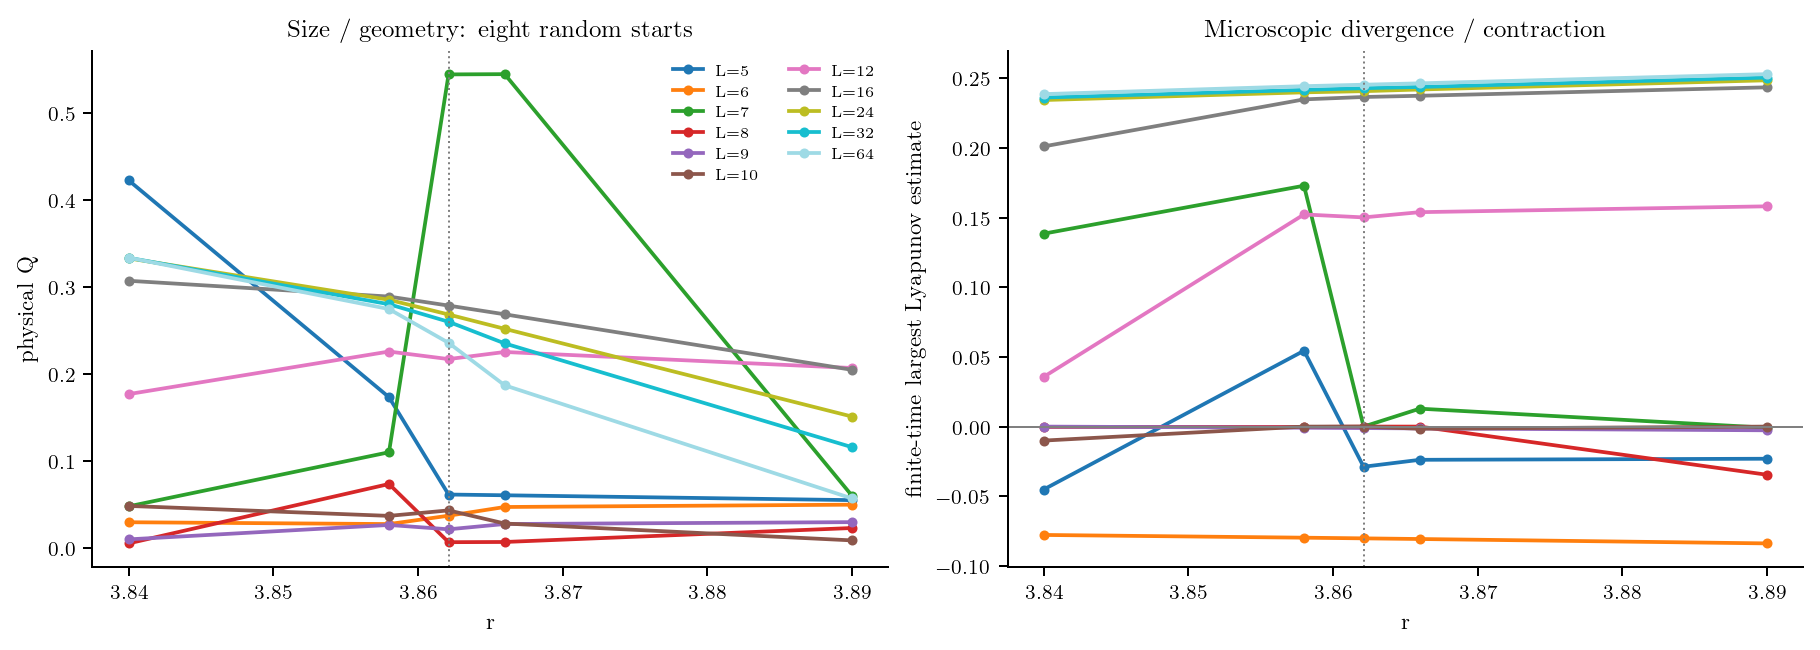

In [25]:
structure_root = ROOT / 'data/order_parameter/cml2d_structure_260914'
audit_path = structure_root / 'existing-bank-audit.csv'
audit_members = sorted((structure_root / 'audit').glob('audit-*.json'))
if audit_path.exists() or len(audit_members) == 1360:
    structure_audit = pd.read_csv(audit_path) if audit_path.exists() else pd.DataFrame([json.loads(p.read_text()) for p in audit_members])
    assert len(structure_audit) == 1360 and structure_audit.case_index.nunique() == 1360
    pass
    pass
    pass
if not (structure_root / 'complete.json').exists():
    pass
else:
    structure_scout = pd.read_csv(structure_root / 'structural-scout.csv')
    base = structure_scout.query("preparation == 'random'")
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
    size_colors = plt.get_cmap('tab20')(np.linspace(0, 1, base.L.nunique()))
    for color, (L, group) in zip(size_colors, base.groupby('L')):
        curve = group.groupby('r')[['Q', 'lyapunov_mean']].mean()
        axes[0].plot(curve.index, curve.Q, 'o-', ms=3, color=color, label=f'L={L}')
        axes[1].plot(curve.index, curve.lyapunov_mean, 'o-', ms=3, color=color)
    for ax in axes:
        ax.axvline(3.86212, color='.5', ls=':', lw=0.8)
        ax.set_xlabel('r')
        paper_axis(ax)
    axes[0].set(ylabel='physical Q', title='Size / geometry: eight random starts')
    axes[0].legend(frameon=False, ncol=2, fontsize=6)
    axes[1].axhline(0, color='.5', lw=0.8)
    axes[1].set(ylabel='finite-time largest Lyapunov estimate', title='Microscopic divergence / contraction')
    for suffix in ('png', 'svg'):
        fig.savefig(ROOT / f'notebooks/inference/figures/lean/cml2d-period-doubling/structural-size-diagnostic.{suffix}', dpi=300, bbox_inches='tight')
    plt.show()
    pass

## 6. Coupled Rössler oscillators — mean-frequency entrainment

**System**

$$\dot x_i=-\omega_i y_i-z_i+C(x_j-x_i),\qquad \dot y_i=\omega_i x_i+.15y_i,\qquad \dot z_i=.2+z_i(x_i-10),\quad j\ne i.$$

**Params**

- $(x_i,y_i,z_i)$: state of oscillator $i\in\{1,2\}$; local parameters fixed at $.15,.2,10$.
- $\omega_{1,2}=1\pm\Delta\omega$, with $\Delta\omega=.015$: intrinsic frequency mismatch.
- $C$: diffusive coupling through the two $x$ coordinates.

**Phase diagram paper:** [Rosenblum, Pikovsky & Kurths (1996)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.76.1804) — Fig. 2, frequency-entrainment region in $(C,\Delta\omega)$; Fig. 1(a), phase drift versus locking at fixed $\Delta\omega=.015$.

**Order-param paper:** [Same paper](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.76.1804) — Fig. 2 and accompanying text, mean-frequency difference $\Delta\Omega$. This is a dynamical physical quantity, not a thermodynamic order parameter.

**Control-parameter sweep:** $C\in[.015,.040]$, step $.00125$, 21 points. All six state coordinates observed: $M=N_{\rm state}=6$ (two oscillators), $T=1000$; sample interval $.2$, integration step $.01$, burn 2000, disjoint reference duration 100,000. Independent confirmation uses 32 fresh seeds. No multi-$M,T$ results are available.

**Order-parameter / physical quantity**

$$\phi_i=\operatorname{unwrap}\operatorname{atan2}(y_i,x_i),\qquad Q=|\langle\dot\phi_1\rangle-\langle\dot\phi_2\rangle|.$$

The difference in average rotation rates. Stronger coupling drives it toward zero without requiring identical chaotic amplitudes.

**Results:** frozen confirmation $\rho=.848$; $Q$ and $q$ share the steepest sampled interval $.02625$–$.0275$. Heatmap colours saturate at $\pm3$ robust units to keep $x,y$ visible alongside rare $z$ bursts; inputs are unchanged.

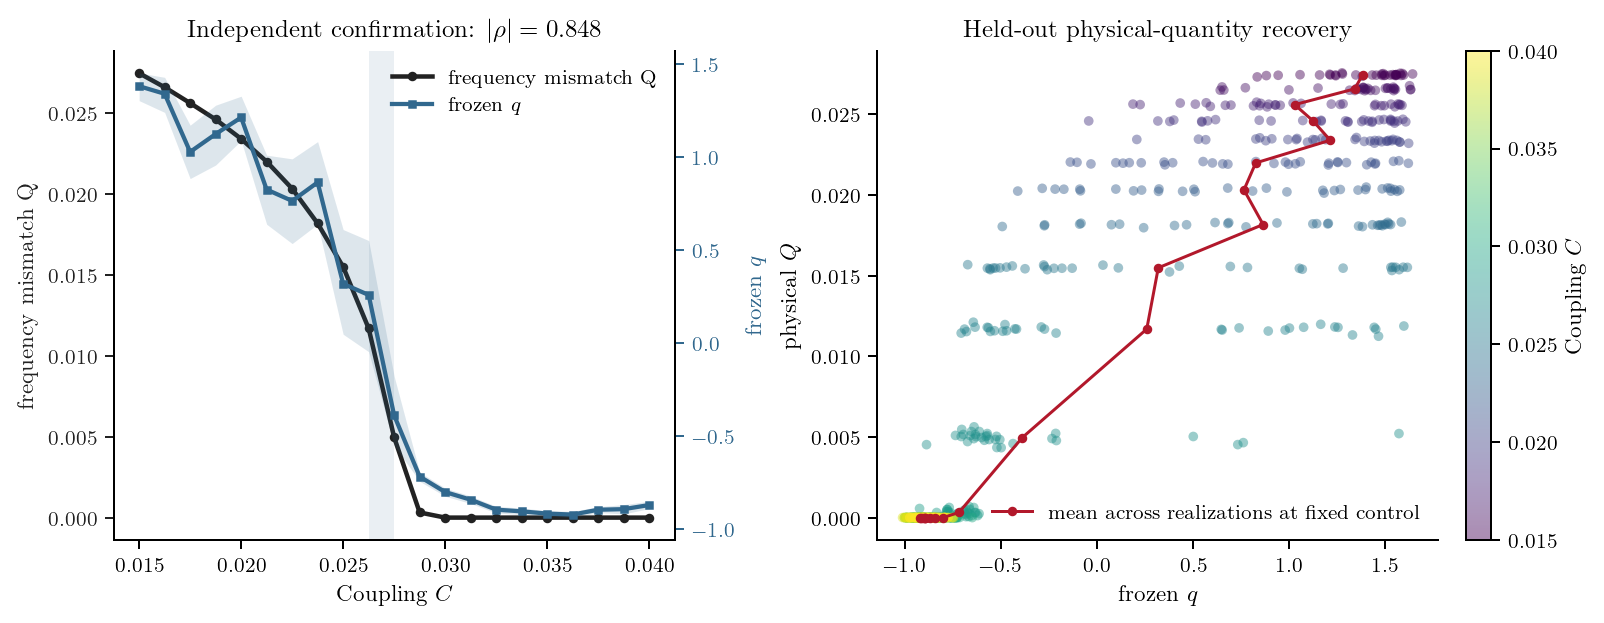

In [26]:
rossler_root=ROOT/"data/order_parameter/finite_regime_260915/rossler/confirmation/primary"
rossler=pd.read_csv(rossler_root/"analysis/scores.csv").query("eligible")
rossler_summary=json.loads((rossler_root/"analysis/summary.json").read_text())
fig,axes=plt.subplots(1,2,figsize=(8.8,3.35),constrained_layout=True)
dual_tracking(axes[0],rossler,control="control",Q="Q_reference",q="q",q_sign=rossler_summary["display_sign"],
    q_color=COLORS[6],title=r"Independent confirmation: $|\rho|=0.848$",Q_label="frequency mismatch Q")
axes[0].set(xlabel=r"Coupling $C$",ylabel="frequency mismatch Q")
axes[0].axvspan(.02625,.0275,color="#31688e",alpha=.1,lw=0)
points=recovery_scatter(axes[1],rossler,Q="Q_reference",q="q",control="control",q_sign=rossler_summary["display_sign"],title="Held-out physical-quantity recovery")
fig.colorbar(points,ax=axes[1],label=r"Coupling $C$")
plt.show()

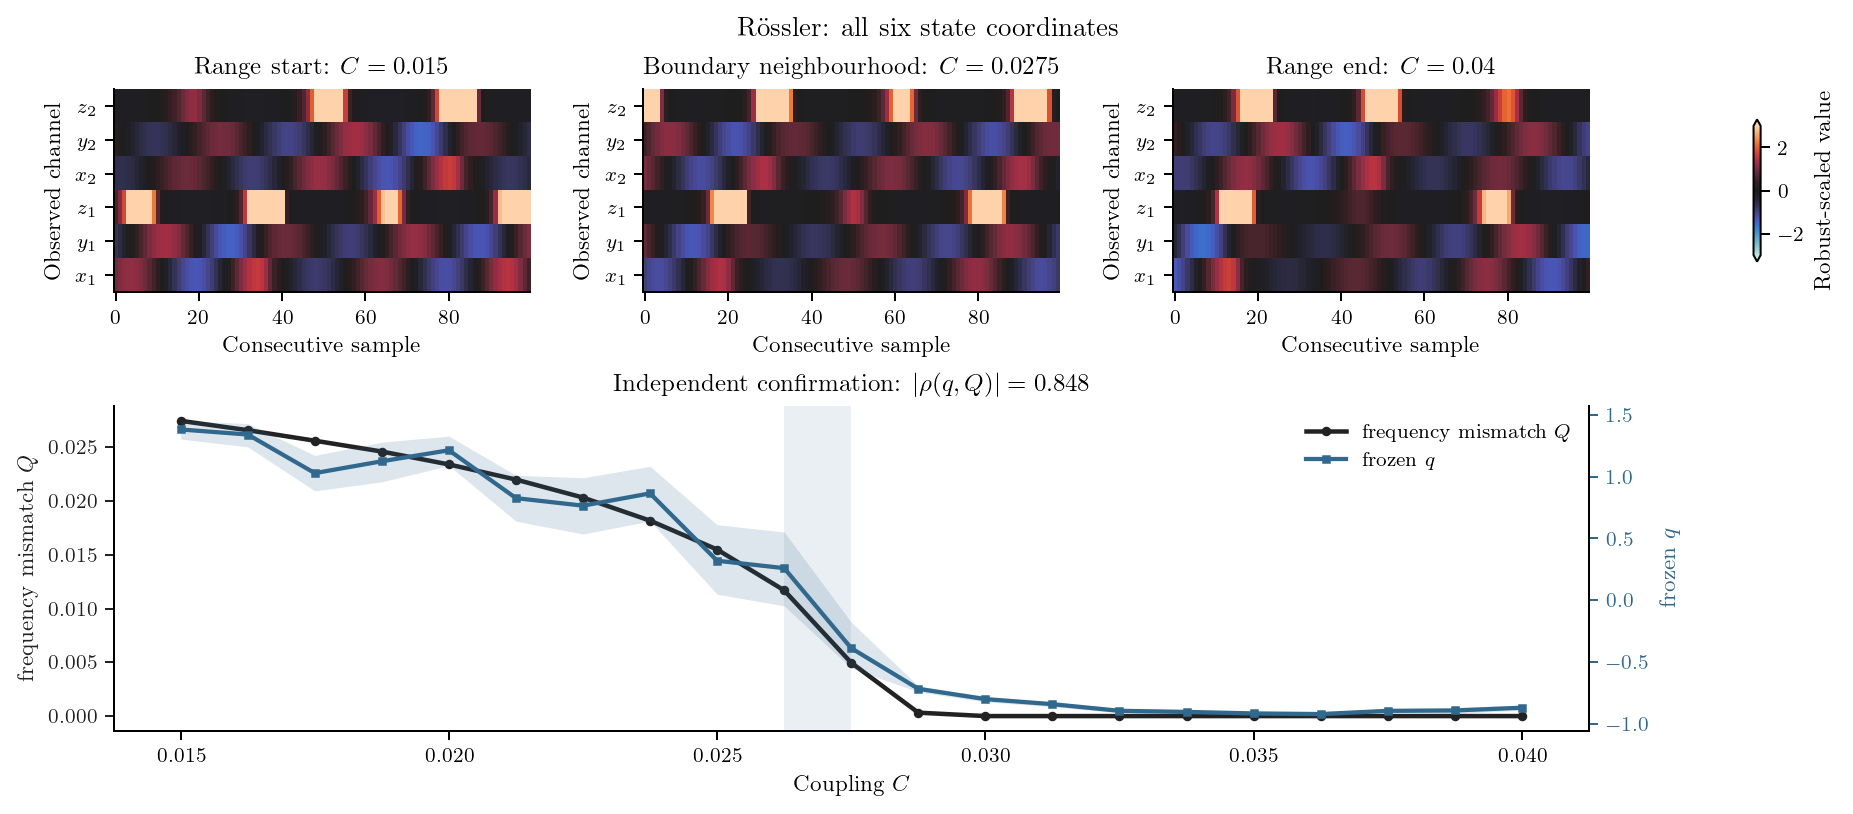

In [27]:
def tracking(ax):
    dual_tracking(ax,rossler,control="control",Q="Q_reference",q="q",q_sign=rossler_summary["display_sign"],
        q_color=COLORS[6],title=r"Independent confirmation: $|\rho(q,Q)|=0.848$",Q_label=r"frequency mismatch $Q$")
    ax.set(xlabel=r"Coupling $C$",ylabel=r"frequency mismatch $Q$")
    ax.axvspan(.02625,.0275,color="#31688e",alpha=.1,lw=0)
composite(corpus_examples(rossler_root,[.015,.0275,.04],2609151001),[.015,.0275,.04],"C",tracking,
    title="Rössler: all six state coordinates",output=FIGURE_DIR/"rossler-composite",
    row_labels=[r"$x_1$",r"$y_1$",r"$z_1$",r"$x_2$",r"$y_2$",r"$z_2$"],robust_limit=3)
plt.show()